# Gene expression analysis

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    
    library(edgeR)
    library(ggrastr)
    library(ggrepel)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
mapping_dir = paste0(main, '07_atlas_mapping/')
out_dir = paste0(main, '09_gene_expression_analysis/')
plot_dir = paste0(main, '09_gene_expression_analysis/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)


source(paste0(main, "mapping_functions.R"))

In [3]:
# X = name of KO
X = 'Eomes'

In [4]:
# Load KO chim data
load_data(remove_doublets = TRUE, remove_stripped = TRUE)
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

# Comparing against WT:WT injection doesn't work well (at least with the new 4 E8.5 samples) maybe retry with only the first 2 samples as their batch effect matches the one from the KO chim better

In [8]:
# load WT:WT data
wt_folder = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/'
counts_wt = readRDS(paste0(wt_folder, "raw_counts.rds"))
genes_wt = read.table(paste0(wt_folder, "genes.tsv"), stringsAsFactors = F)
meta_wt = read.csv(paste0(wt_folder, "meta.tab"), stringsAsFactors = F, sep='\t')
sfs_wt = read.table(paste0(wt_folder, "sizefactors.tab"), stringsAsFactors = F)[,1]

counts_wt = counts_wt[,meta_wt$doublet==FALSE & meta_wt$stripped==FALSE]
sfs_wt = sfs_wt[meta_wt$doublet==FALSE & meta_wt$stripped==FALSE]
meta_wt = meta_wt[meta_wt$doublet==FALSE & meta_wt$stripped==FALSE,]

meta_wt = read.csv(paste0(wt_folder, "meta_complete.csv"), stringsAsFactors = F)

# Correct tdTom annotation
exp_design = data.frame('sample' = c(1,2,3,4,5,6,7,8,9,10), 
                       'tdTom' = c('positive', 'negative',
                                'positive', 'negative',
                                'positive', 'negative',
                                'negative', 'positive',
                                'negative', 'positive'))
meta_wt = merge(meta_wt, exp_design, by='sample')

rownames(counts_wt) = genes_wt[,1] #ensembl
colnames(counts_wt) = meta_wt$cell

sce_wt = SingleCellExperiment(assays = list("counts" = counts_wt))

sizeFactors(sce_wt) = sfs_wt
sce_wt = scater::logNormCounts(sce_wt)

# sce_wt = sce_wt[, meta_wt$stage=='E8.5']
# meta_wt = meta_wt[meta_wt$stage=='E8.5',]

sce_wt = sce_wt[, meta_wt$sample==1] # Select only the first E8.5 tomato+ sample
meta_wt = meta_wt[meta_wt$sample==1,]

#meta_wt$tdTom = ifelse(meta_wt$tomato==TRUE, 'positive', 'negative')
head(meta_wt, 2)

,sample,cell,barcode,stage,tomato,index,doub.density,doublet,stripped,umap_1,umap_2,louvain_cluster,celltype.mapped,stage.mapped,closest.cell,celltype.score,cellstage.score,umapX.mapped,umapY.mapped,tdTom
,<int>,<chr>,<chr>,<chr>,<lgl>,<int>,<dbl>,<lgl>,<lgl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,1,cell_1,AAACCTGAGACTGTAA,E8.5,TRUE,1,18.25423,FALSE,FALSE,6.5531859,4.812458,1,Mesenchyme,E8.25,cell_97660,1,0.4333333,-6.064576,13.24414,positive
2,1,cell_2,AAACCTGAGATGCCTT,E8.5,TRUE,2,19.32801,FALSE,FALSE,-0.2231502,13.654447,23,Endothelium,E8.5,cell_96660,1,0.5666667,-2.187918,17.50636,positive


In [9]:
table(meta_wt$tdTom, meta_wt$sample)

          
              1
  positive 2254

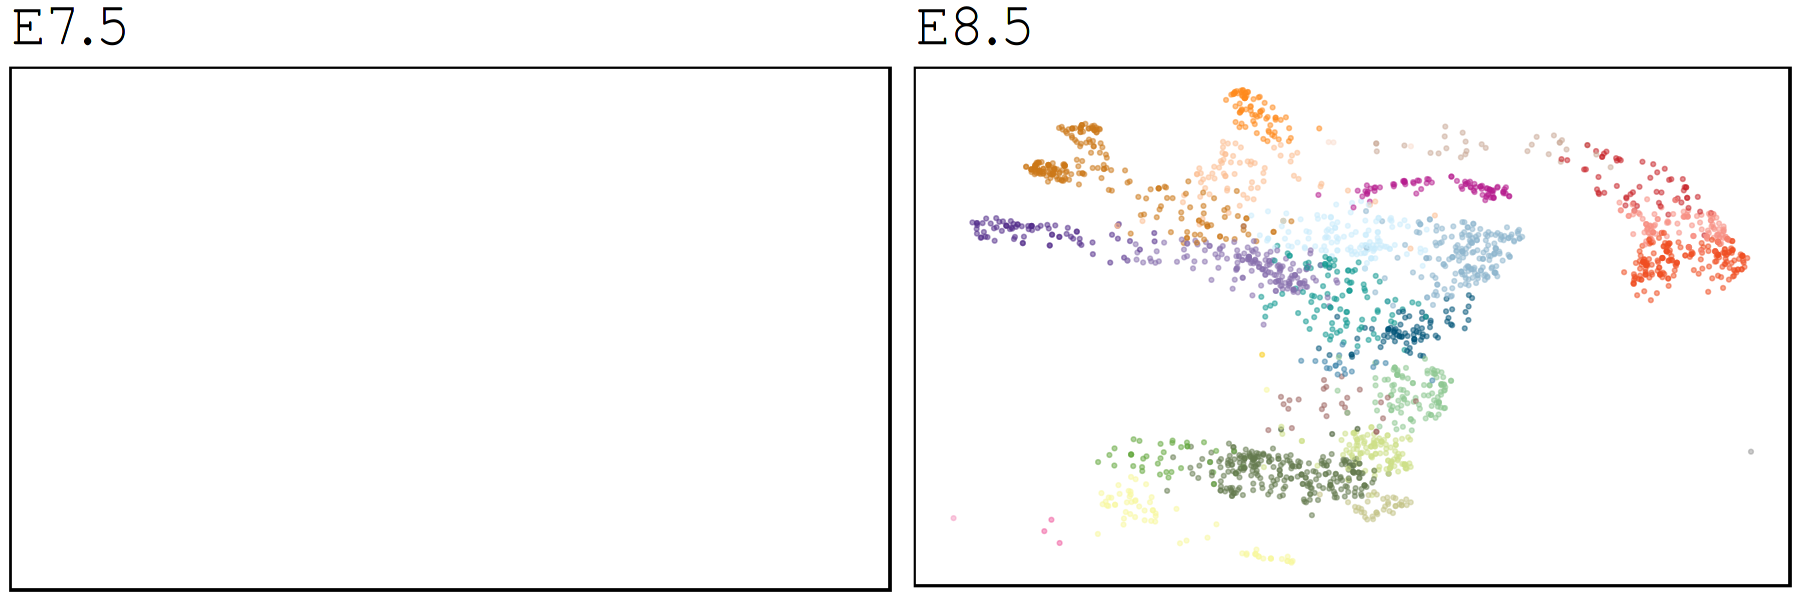

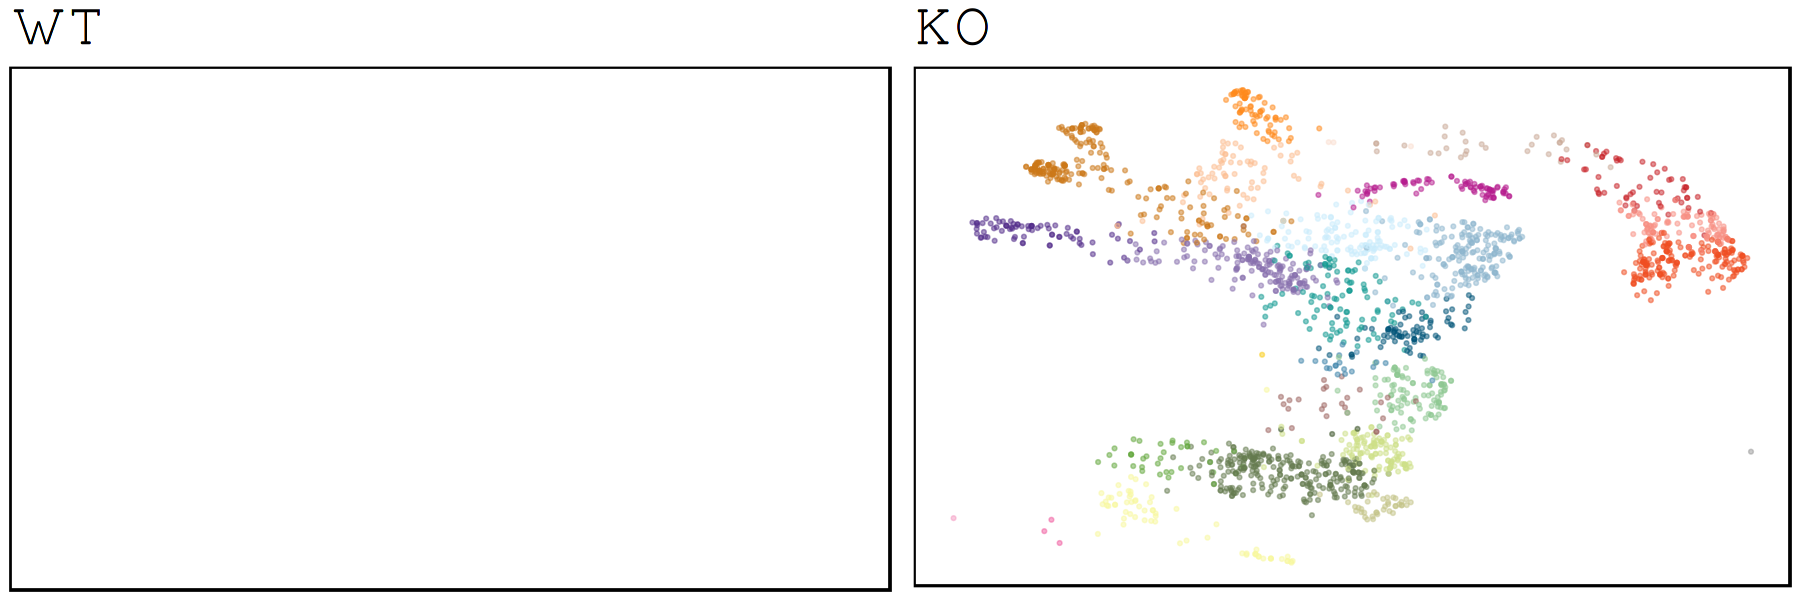

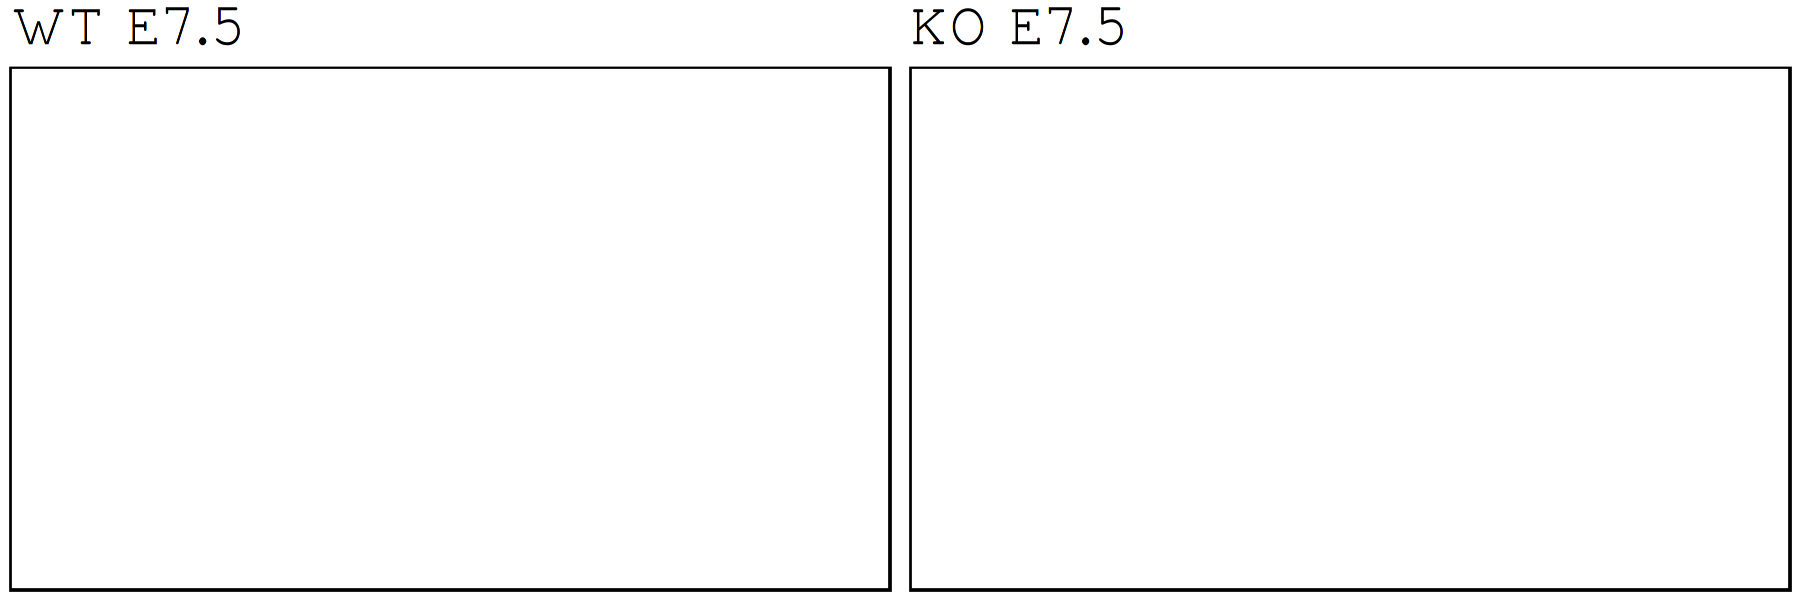

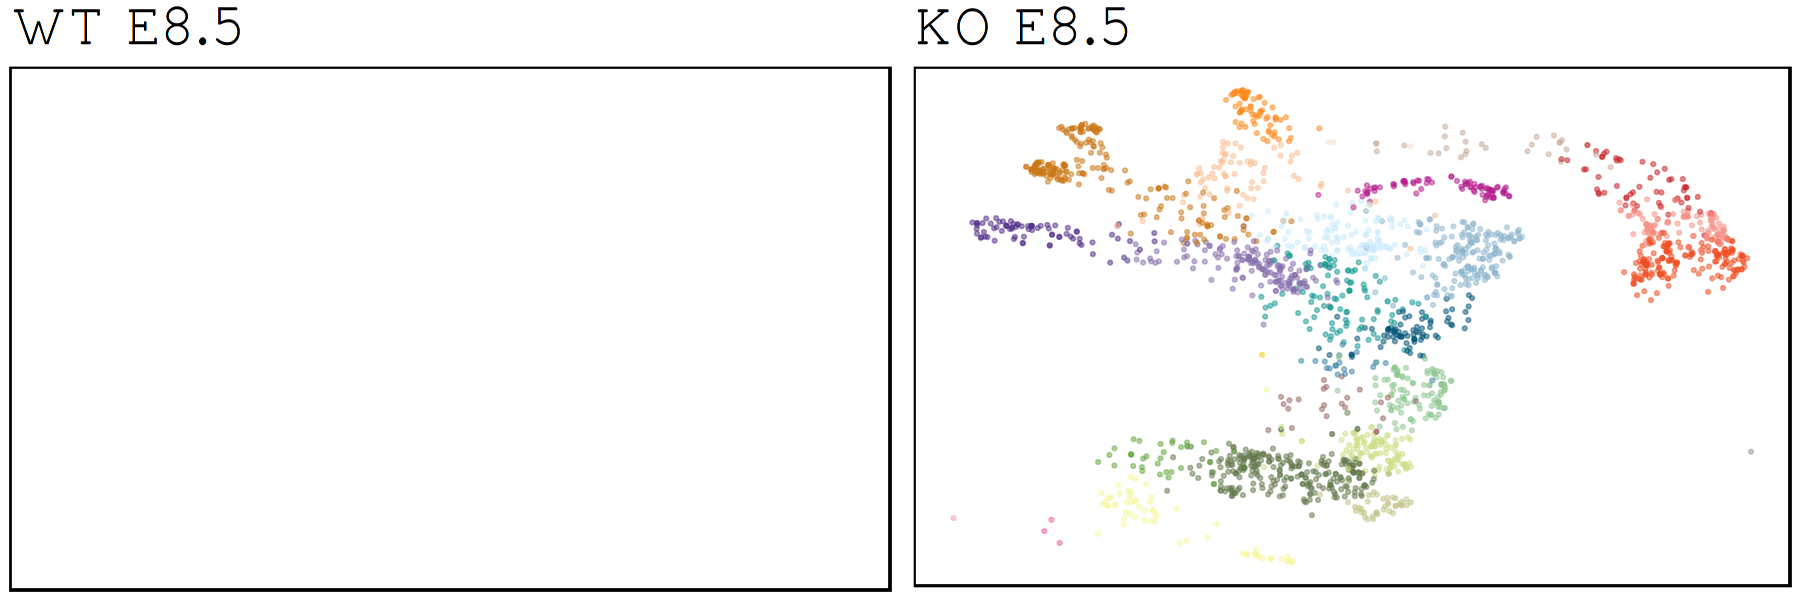

In [10]:
meta_wt$umap_1 = as.numeric(meta_wt$umap_1)
meta_wt$umap_2 = as.numeric(meta_wt$umap_2)
options(repr.plot.width=15, repr.plot.height=5)

p1 = ggplot(meta_wt[meta_wt$stage=='E7.5',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('E7.5')
p2 = ggplot(meta_wt[meta_wt$stage=='E8.5',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('E8.5')
grid.arrange(p1,p2,ncol=2)

p1 = ggplot(meta_wt[meta_wt$tdTom=='negative',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('WT')
p2 = ggplot(meta_wt[meta_wt$tdTom=='positive',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('KO')
grid.arrange(p1,p2,ncol=2)

p1 = ggplot(meta_wt[meta_wt$tdTom=='negative' & meta_wt$stage=='E7.5',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('WT E7.5')
p2 = ggplot(meta_wt[meta_wt$tdTom=='positive' & meta_wt$stage=='E7.5',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('KO E7.5')
grid.arrange(p1,p2,ncol=2)
p1 = ggplot(meta_wt[meta_wt$tdTom=='negative' & meta_wt$stage=='E8.5',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('WT E8.5')
p2 = ggplot(meta_wt[meta_wt$tdTom=='positive' & meta_wt$stage=='E8.5',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('KO E8.5')
grid.arrange(p1,p2,ncol=2)

In [11]:
# Match meta column names
meta_wt = meta_wt[, colnames(meta)[colnames(meta) %in% colnames(meta_wt)]]
meta = meta[, colnames(meta)[colnames(meta) %in% colnames(meta_wt)]]

# Make metas compatible
meta$cell = paste0(X, '_', meta$cell)
colnames(sce) = meta$cell
meta_wt$cell = paste0('WT_', meta_wt$cell)
colnames(sce_wt) = meta_wt$cell

meta$exp = X
meta_wt$exp = 'WT'

In [12]:
## Keep only shared genes
# genes shared across datasets
shared_genes = merge(data.frame('V1'=names(sce)), data.frame('V1'=names(sce_wt)), by='V1')

# filter cells & genes chimera dataset
sce = sce[shared_genes$V1,]

# filter cells & genes WT dataset
sce_wt = sce_wt[shared_genes$V1,]

In [13]:
# Keep only injected cells from both experiments
sce = sce[,meta$tdTom=='positive']
meta = meta[meta$tdTom=='positive',]

sce_wt = sce_wt[,meta_wt$tdTom=='positive']
meta_wt = meta_wt[meta_wt$tdTom=='positive',]

In [14]:
# Merge the datasets
meta = rbind(meta, meta_wt)
sce = cbind(sce, sce_wt)

In [15]:
meta$exp = factor(meta$exp, levels=c(X, 'WT'))

In [16]:
meta$umap_1 = as.numeric(meta$umap_1)
meta$umap_2 = as.numeric(meta$umap_2)

In [17]:
genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
genenames = genenames[genenames$gene %in% rownames(sce)]
genenames = merge(genenames, as.data.frame(rownames(sce)), by.x='gene', by.y='rownames(sce)', all.y=TRUE)
genenames$gene_name[genenames$gene_name==''] = NA
genenames[is.na(genenames$gene_name),] = genenames$gene[is.na(genenames$gene_name)]
genenames = genenames[order(match(genenames$gene, rownames(sce)))]
rownames(sce) = genenames$gene_name

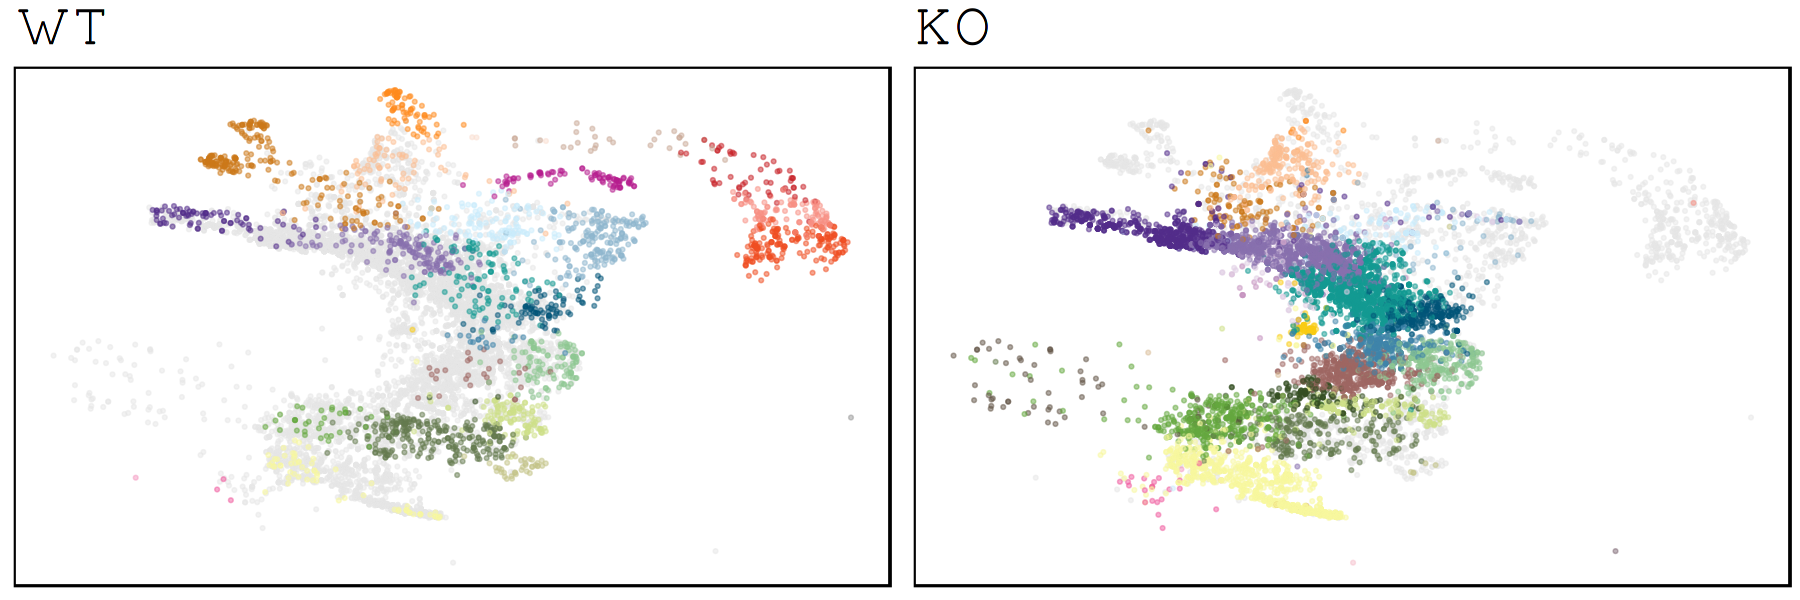

In [18]:
p1 = ggplot(meta[meta$exp=='WT',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(data=meta[meta$exp!='WT',], aes(umapX.mapped, umapY.mapped), size = 0.7, alpha = 0.5,col='grey90') +
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('WT')
p2 = ggplot(meta[meta$exp==X,], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
        geom_point(data=meta[meta$exp=='WT',], aes(umapX.mapped, umapY.mapped), size = 0.7, alpha = 0.5,col='grey90') +
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme + ggtitle('KO')
grid.arrange(p1,p2,ncol=2)

### Interrogation of specific gene sets

In [19]:
WT = meta[meta$exp=='WT',]
KO =  meta[meta$exp!='WT',]

ct_nr = reshape2::dcast(as.data.frame(table(meta$celltype.mapped, meta$exp)), Var1 ~ Var2)
keep = ct_nr[ct_nr[,2]>10 & ct_nr[,3]>10,]$Var1

meta_seurat = meta[meta$celltype.mapped %in% keep,]
rownames(meta_seurat) = meta_seurat$cell
counts = counts(sce[,meta_seurat$cell])
colnames(counts) = meta_seurat$cell


seurat = CreateSeuratObject(counts, project = "SeuratProject", assay = "RNA",
  min.cells = 0, min.features = 0, meta =meta_seurat)

seurat[['logcounts']] = CreateAssayObject(counts = logcounts(sce[,meta_seurat$cell]))
DefaultAssay(seurat) = 'logcounts'

Using Freq as value column: use value.var to override.

Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”


In [20]:
plot_gene = function(x){

    gene = logcounts(sce[x,])/max(logcounts(sce[x,]))
      
    p1 = ggplot(WT, aes(umapX.mapped, umapY.mapped, col=as.vector(gene[,cell]))) + 
        geom_point(data=KO, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(x), 
             subtitle = 'WT') +
        umap_theme + theme(plot.margin = unit(c(1, 0.5, -4, 1), "lines"))
    p2 = ggplot(KO, aes(umapX.mapped, umapY.mapped, col=as.vector(gene[,cell]))) + 
        geom_point(data=WT, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        umap_theme + theme(plot.margin = unit(c(1, 1, -4, 0.5), "lines"))
    
    legend_plot = ggplot(meta, aes(umapX.mapped, umapY.mapped, col=as.vector(logcounts(sce[x,])))) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma', name='Expr') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        theme_bw()+ theme(legend.position = c(0.2, 0.3), 
                          text = element_text(color='black'))
    p1_legend = cowplot::get_legend(legend_plot)
    
df = data.frame('cell'=meta$cell, 'celltype' = meta$celltype.mapped, 'tdTom'= meta$exp, 'gene'= as.vector(logcounts(sce[x,])))
df = df %>% group_by(celltype, tdTom) %>% summarize('mean' = mean(gene))#/max(gene))

    p3=ggplot(df[df$celltype %in% keep,], aes(celltype, tdTom, fill=mean)) +       
        scale_fill_viridis(option='magma', name='', end = max(df$mean)/max(as.vector(logcounts(sce[x,])))) + 
        scale_y_discrete(labels=c('KO', 'WT'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 20, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 14, color='black'),
              axis.text.x=element_blank(),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.15, plot.margin = unit(c(-5, 1, -5, 1), "lines"))

    p4 = VlnPlot(seurat,x,split.by='exp', group.by='celltype.mapped', pt.size=0, split.plot = TRUE) + 
                scale_fill_manual(values = c('red', 'black')) +
        ylab('')+
        theme(axis.title.x=element_blank(),
              axis.title.y=element_text(size=0), 
              text= element_text(size = 30, color='black'), 
              axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 13, color='black'),
             # axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2,
              plot.title = element_blank(), plot.margin = unit(c(-5, 1, -3, 1), "lines"))
    
    grid.arrange(arrangeGrob(p1, p2, p1_legend, ncol=3, widths=c(1,1,0.1)), p3, p4, ncol=1)
}


In [21]:
# for mai-linh
genes = c('Tgfbr1','Tgfbr2','Tgfbr3', 'Bmp1', 'Bmp2', 'Bmp3', 'Bmp4', 'Bmp5', 'Bmp6', 'Bmp7', 'Acvr1', 'Acvr1b', 'Acvr1c', 'Mixl1', 'Eomes', 'T')
genes = genes[genes %in% rownames(sce)]

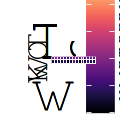

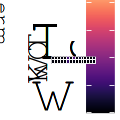

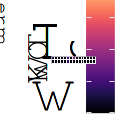

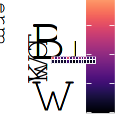

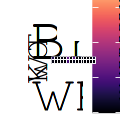

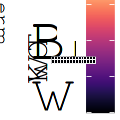

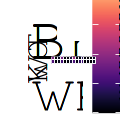

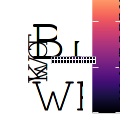

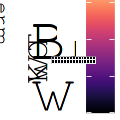

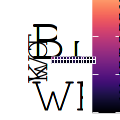

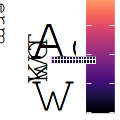

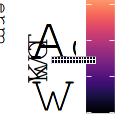

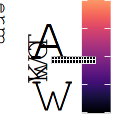

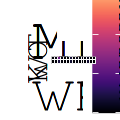

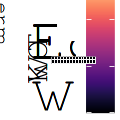

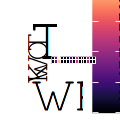

In [22]:
options(repr.plot.width=1, repr.plot.height=1)
plots = list()
for(i in 1:length(genes)){
   plots[[i]] = suppressMessages(plot_gene(genes[i]))
    }
names(plots) = genes
options(repr.plot.width=10, repr.plot.height=8)


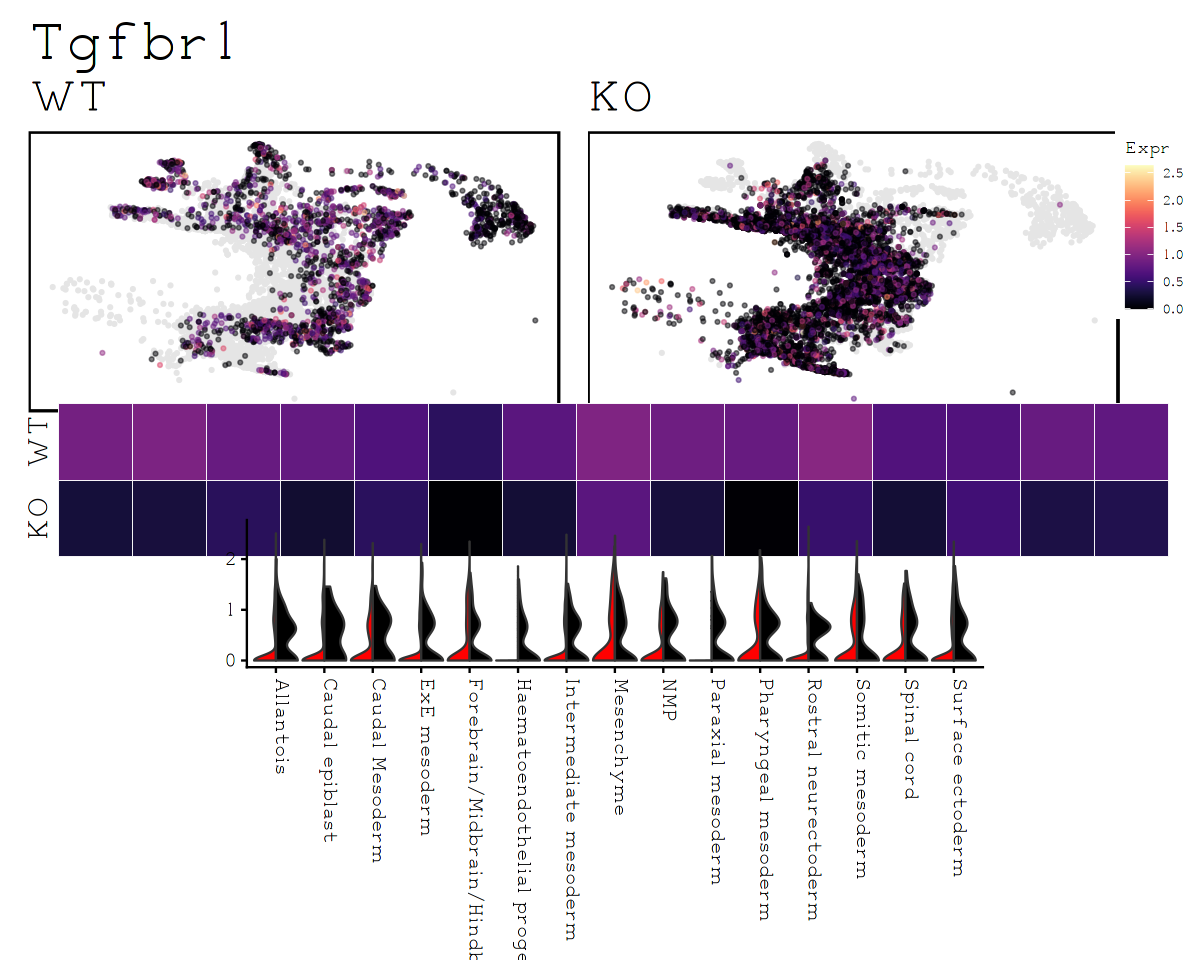

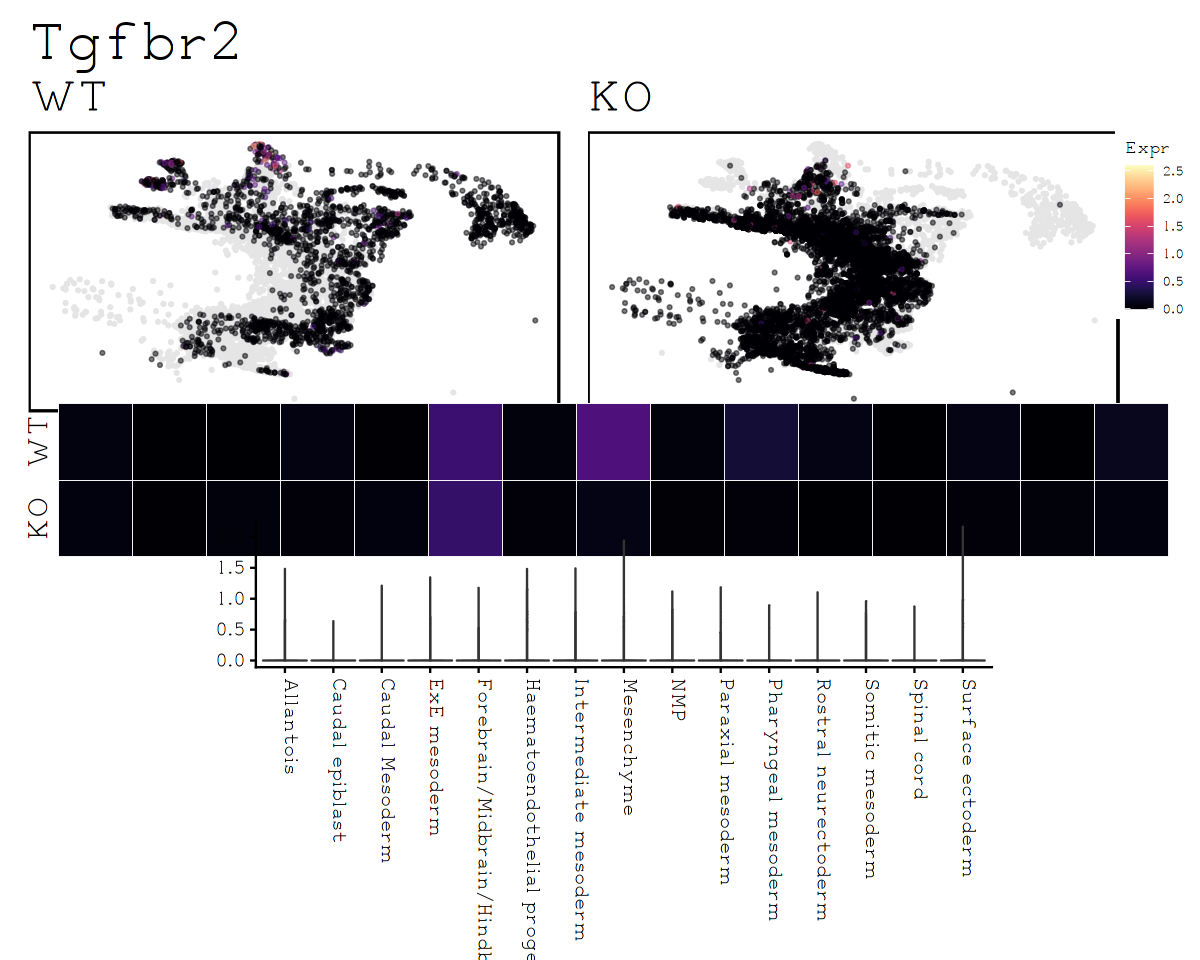

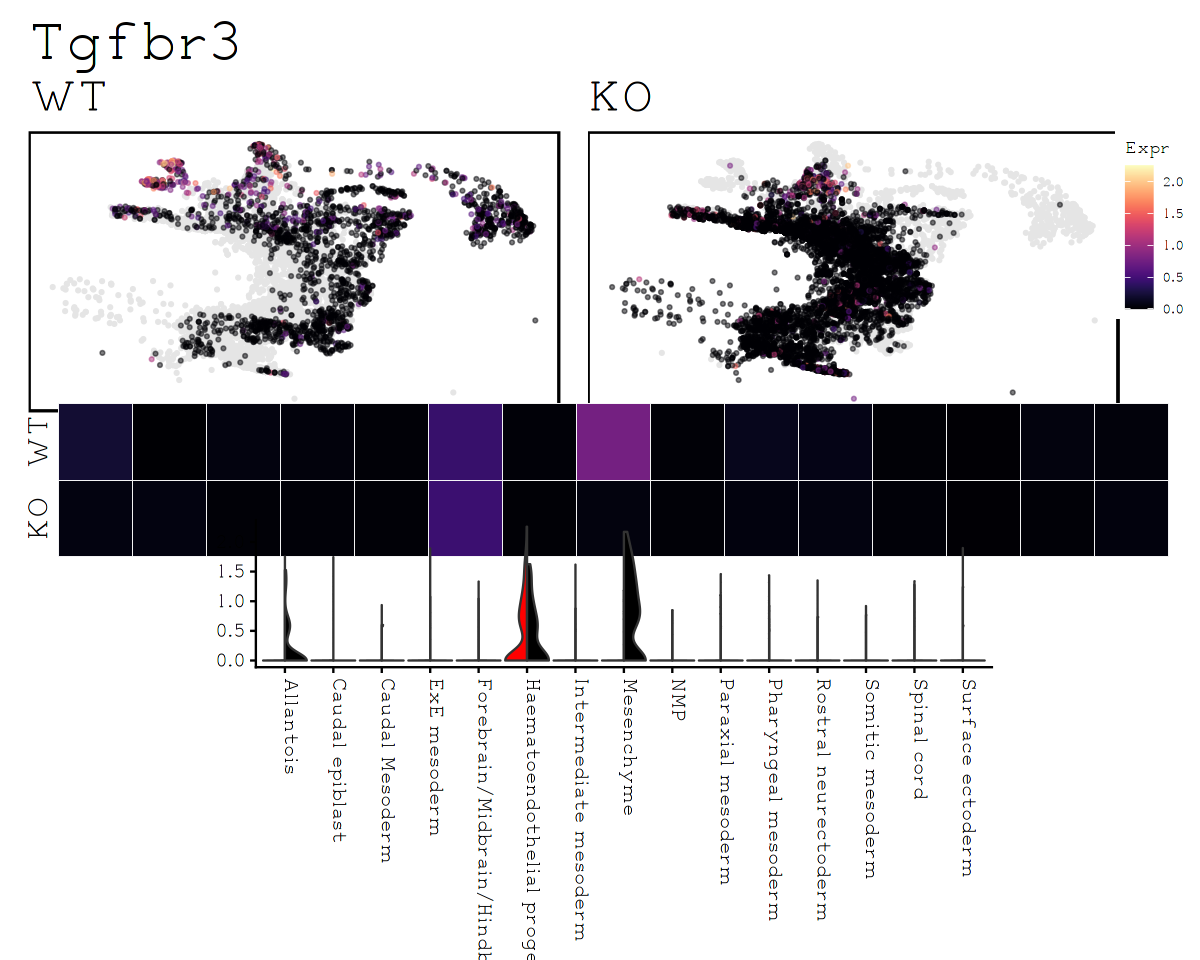

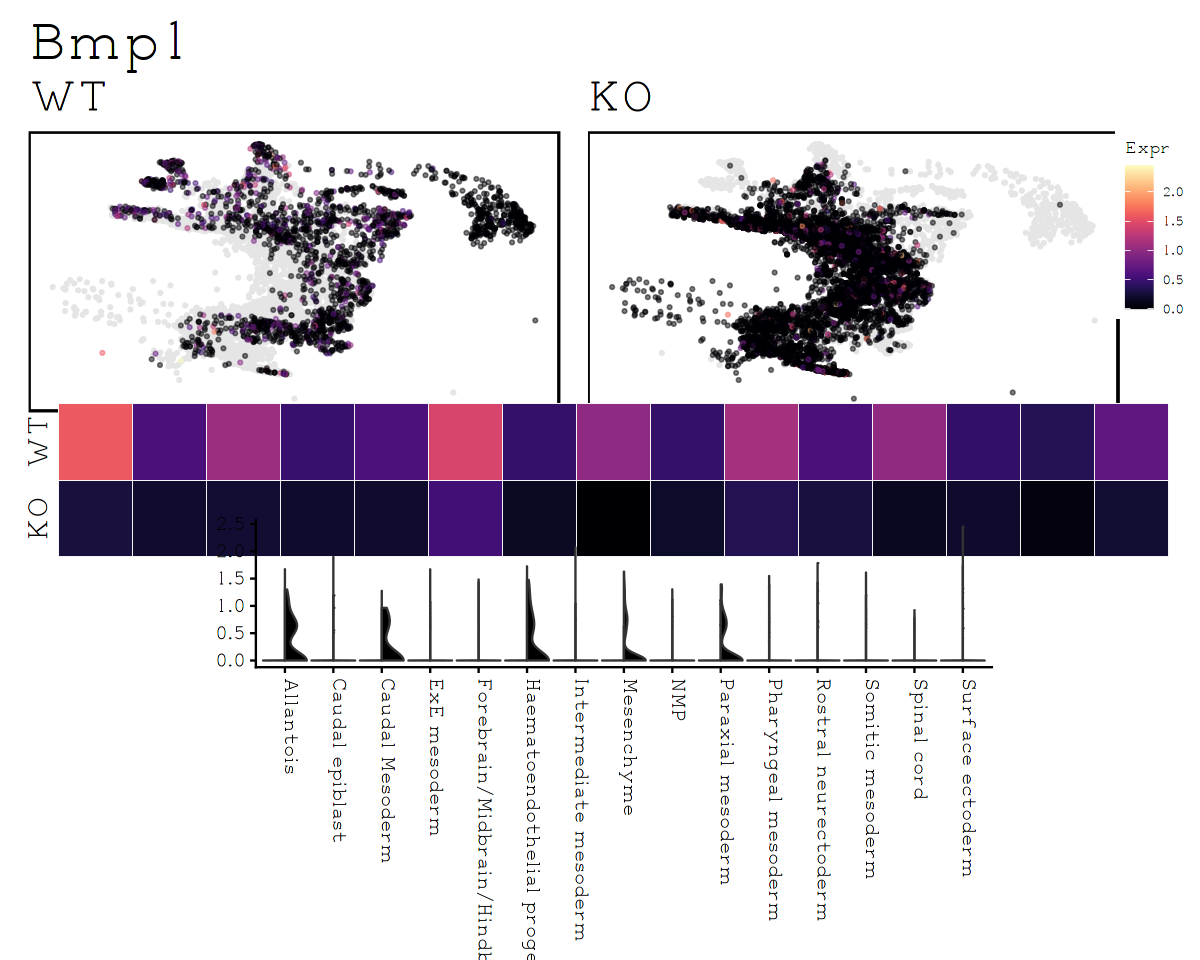

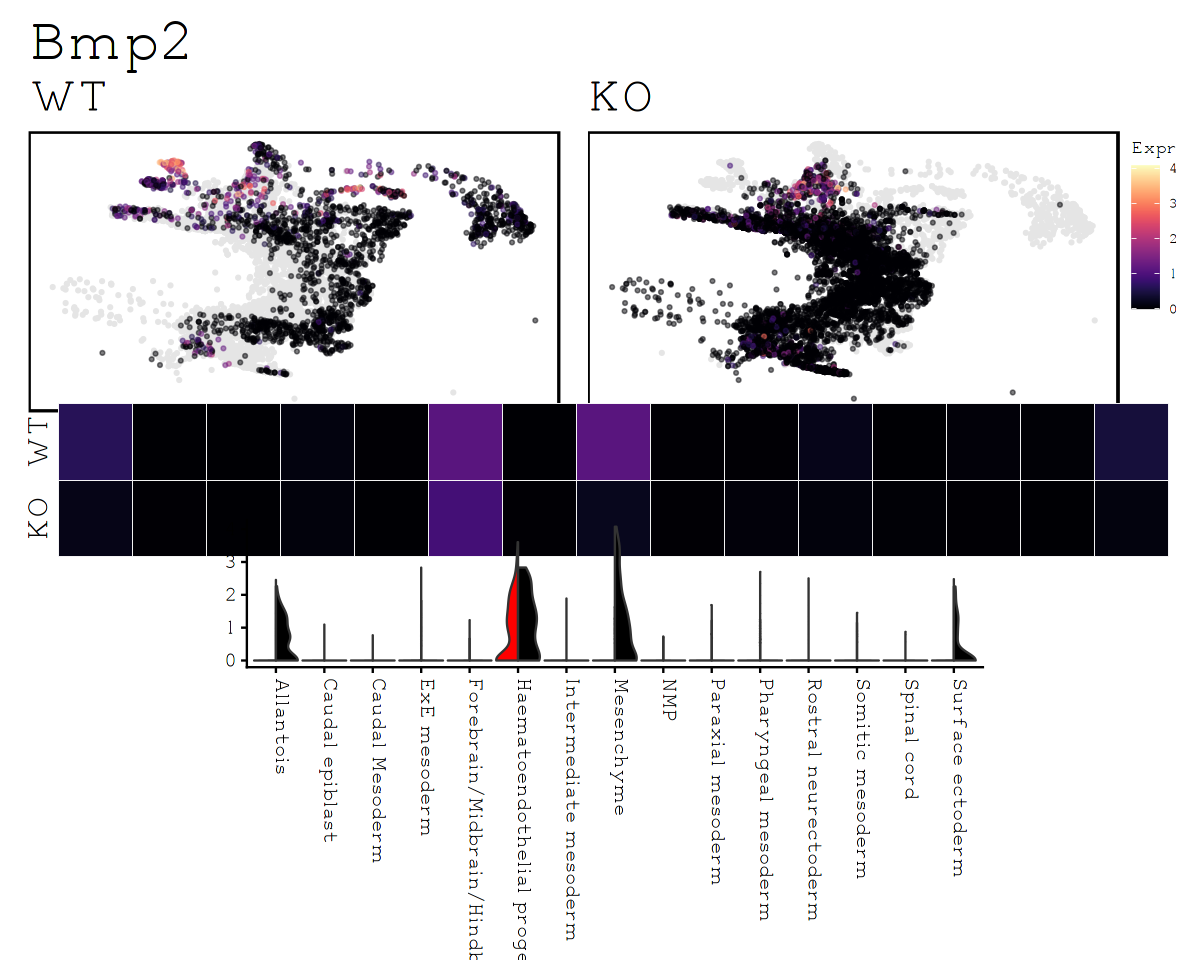

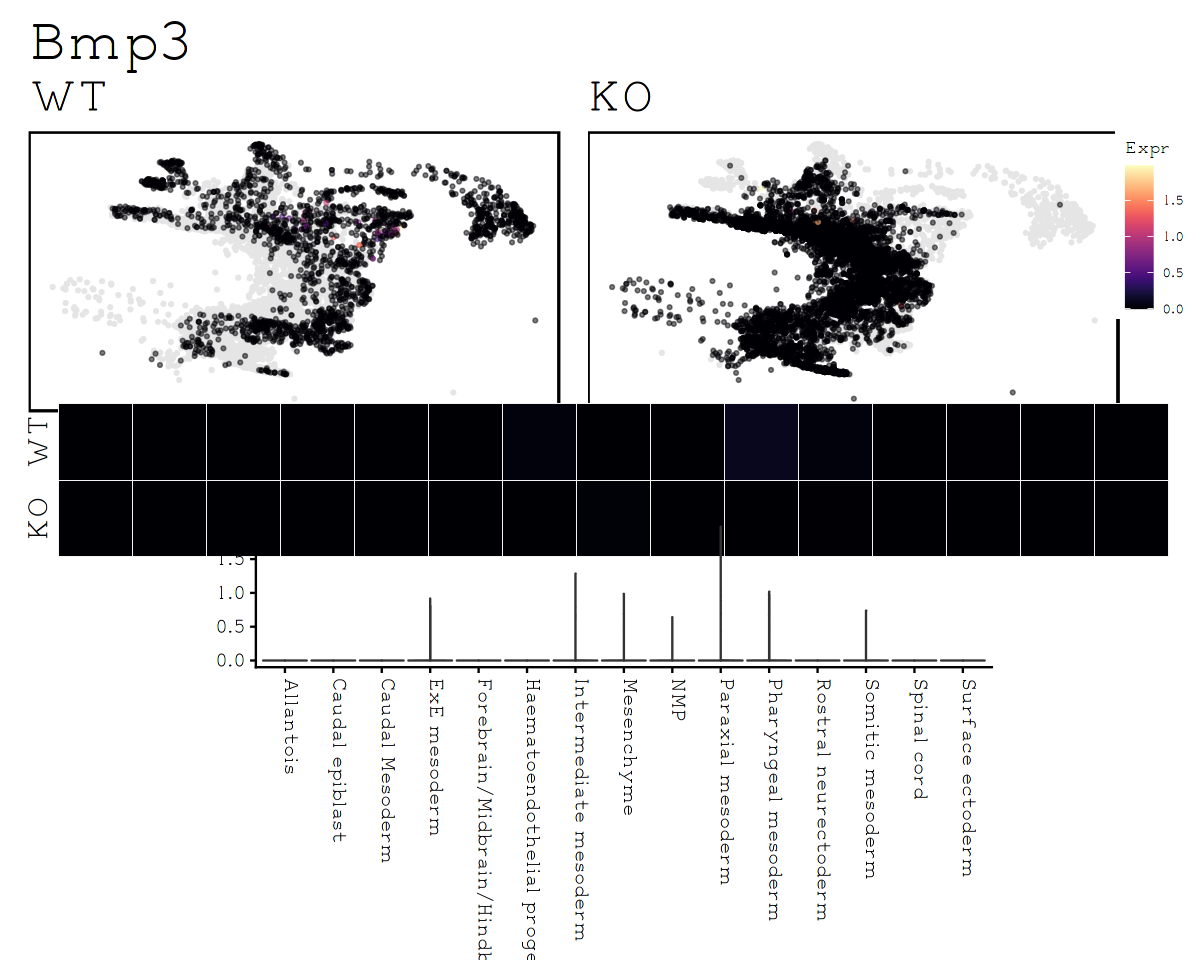

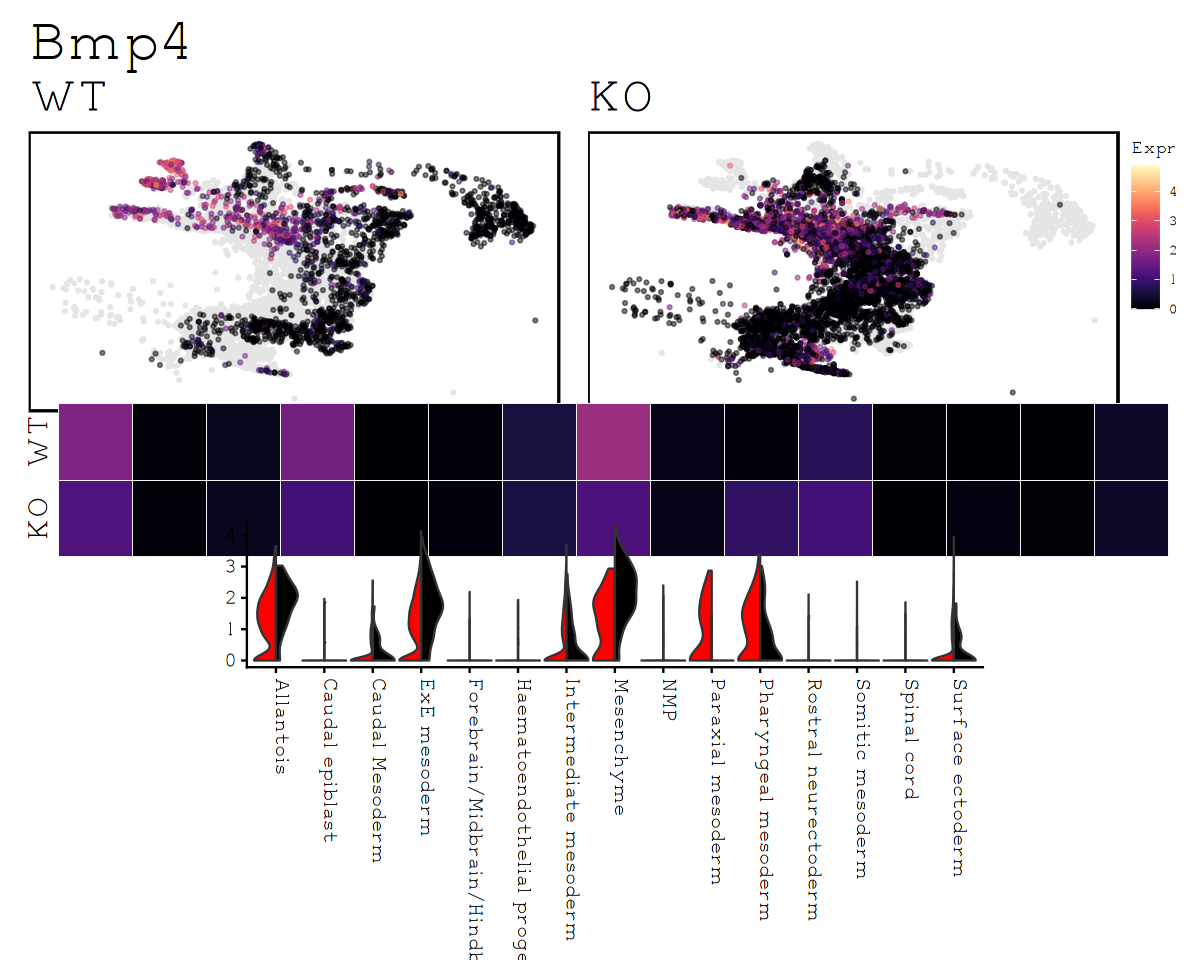

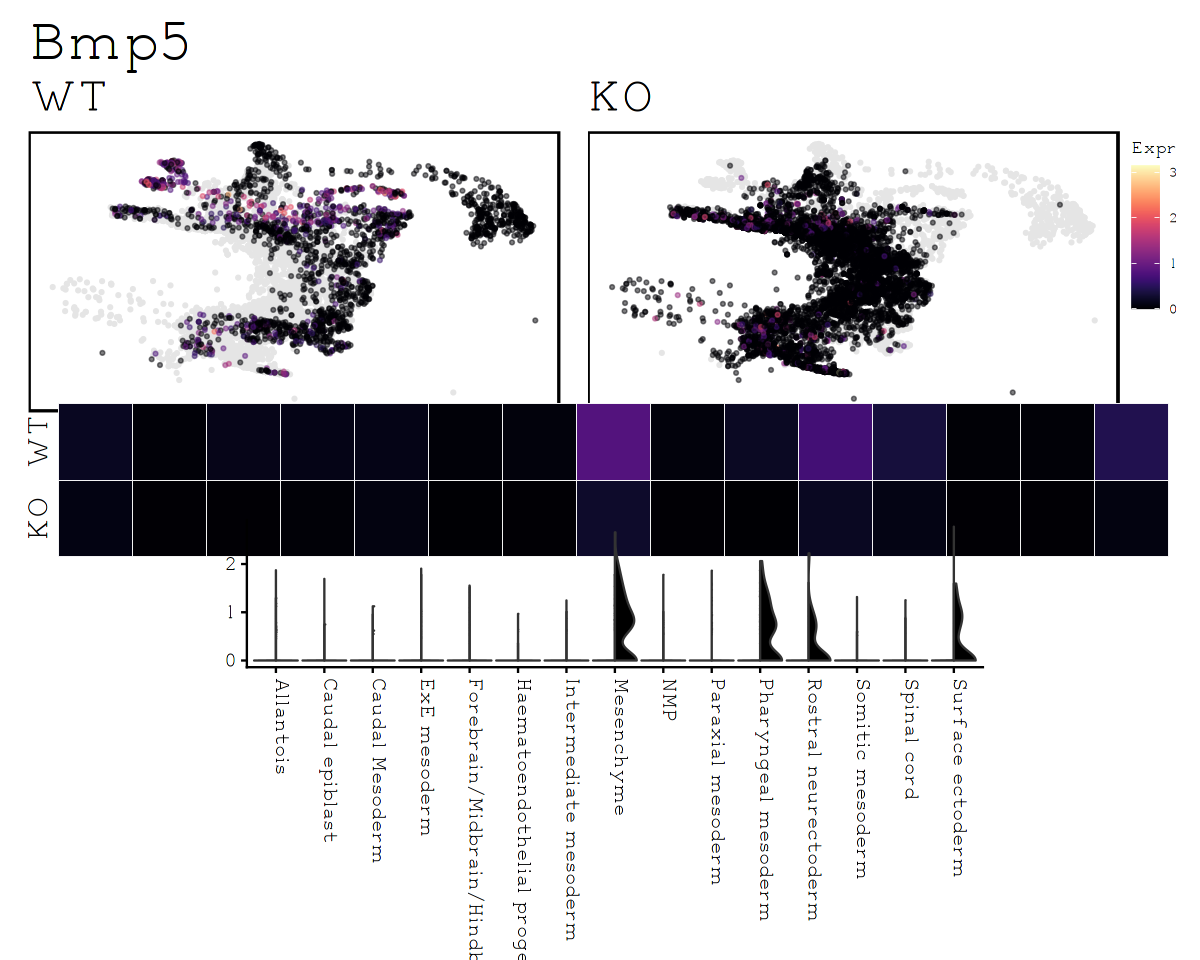

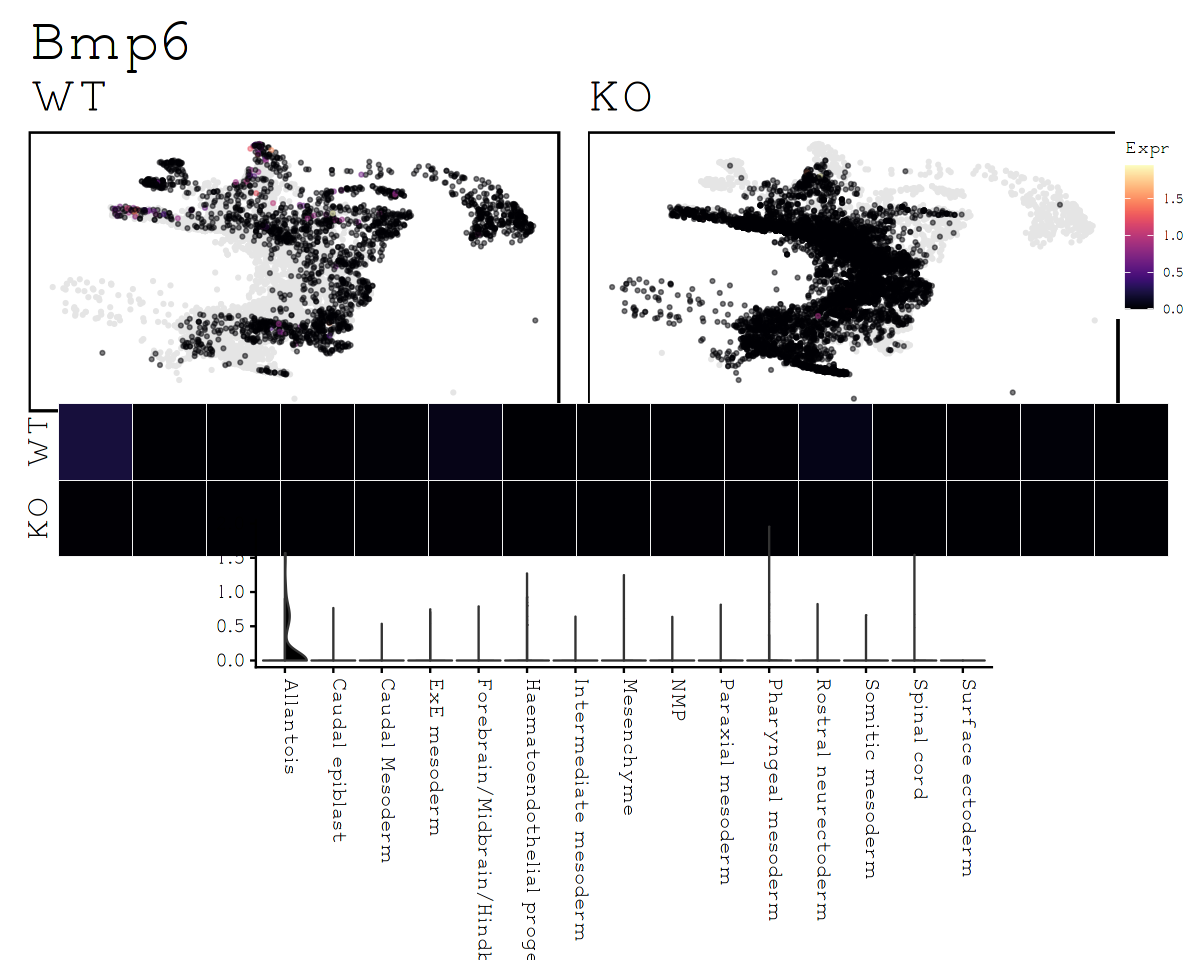

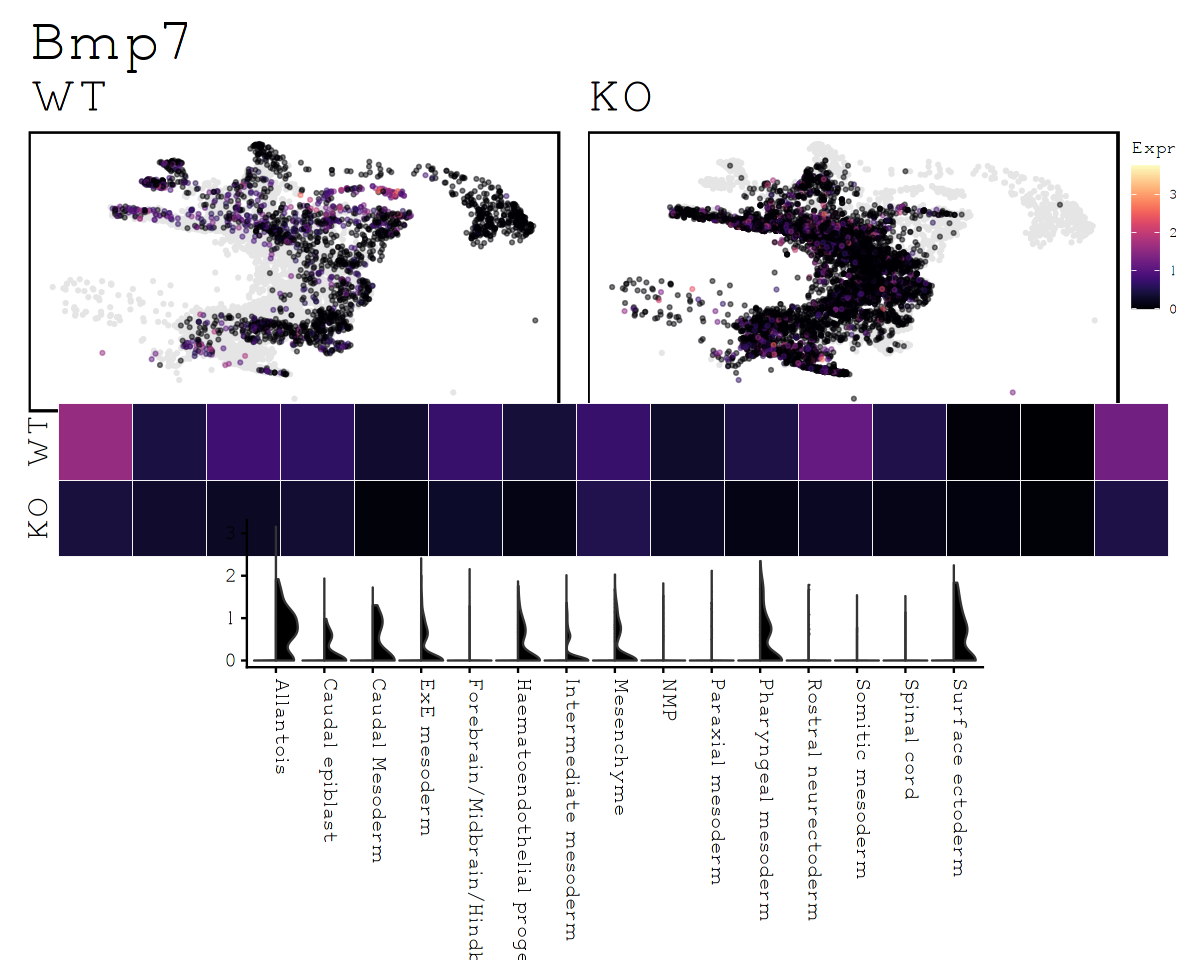

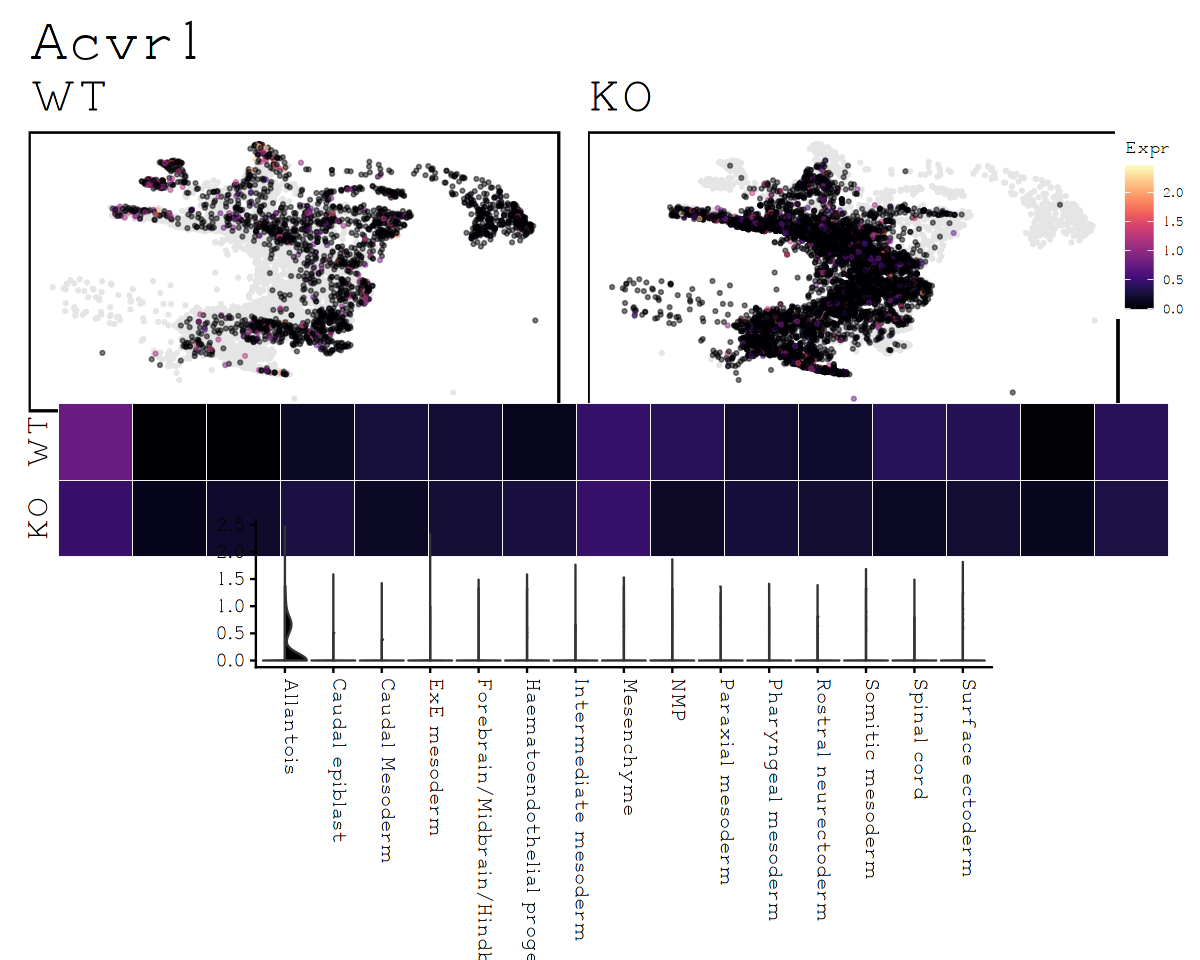

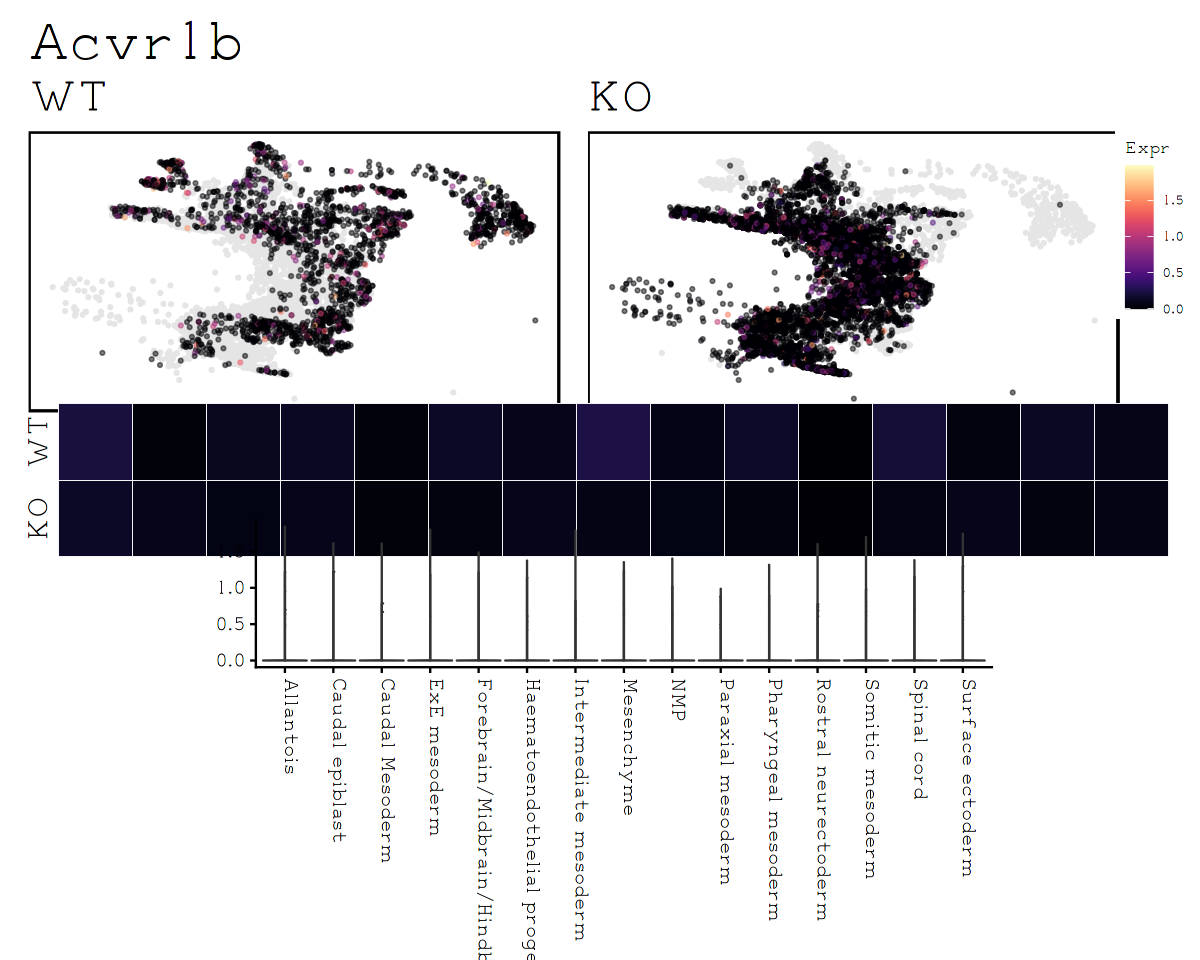

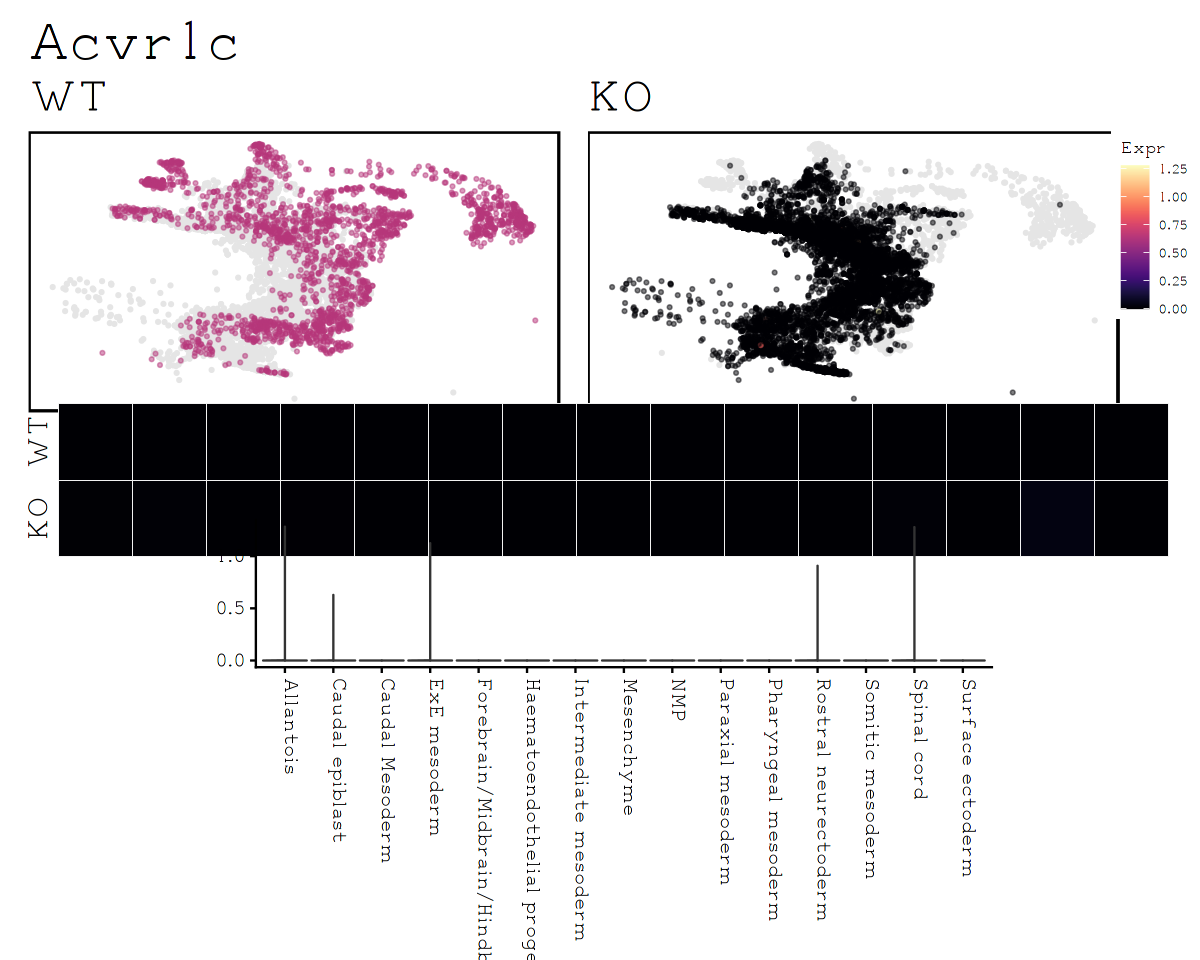

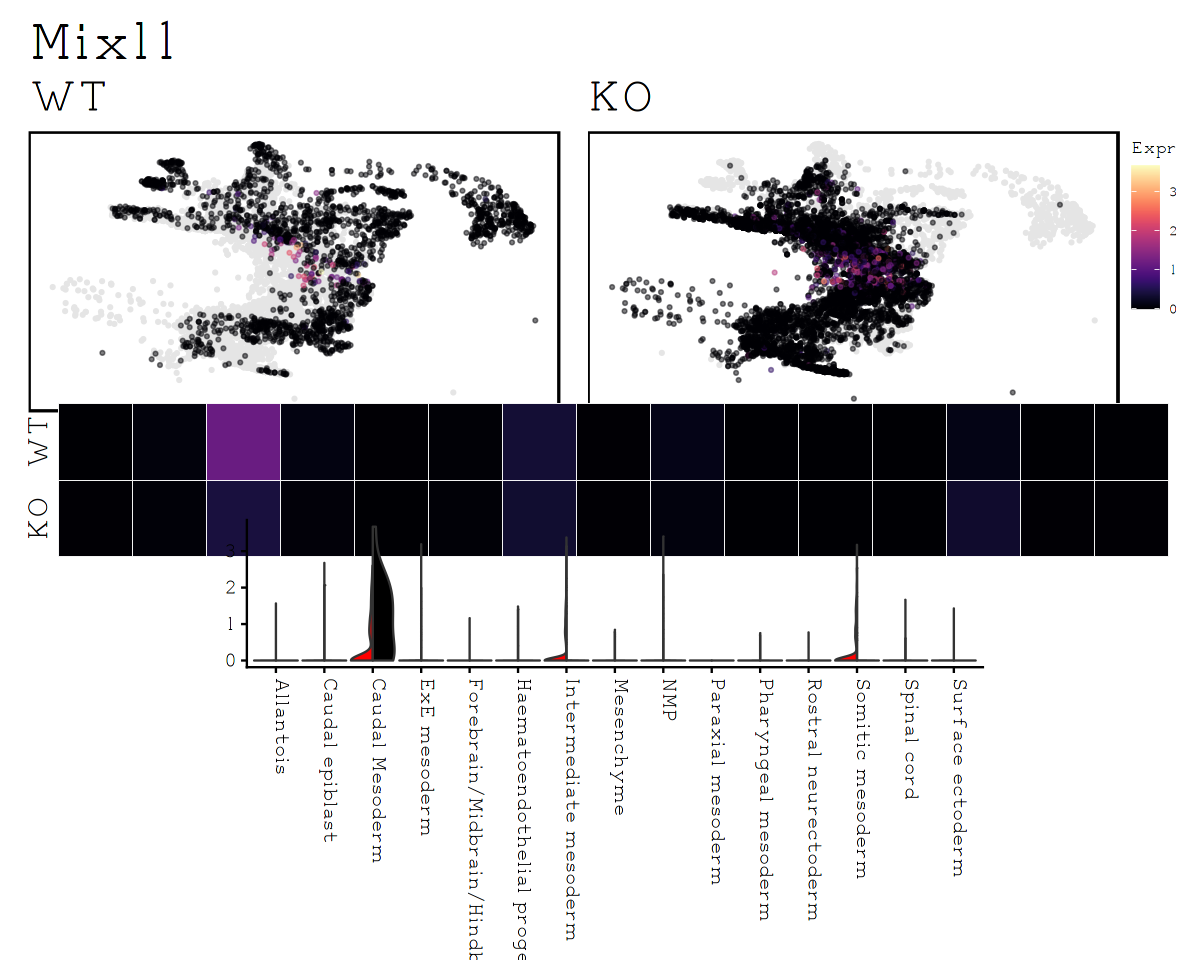

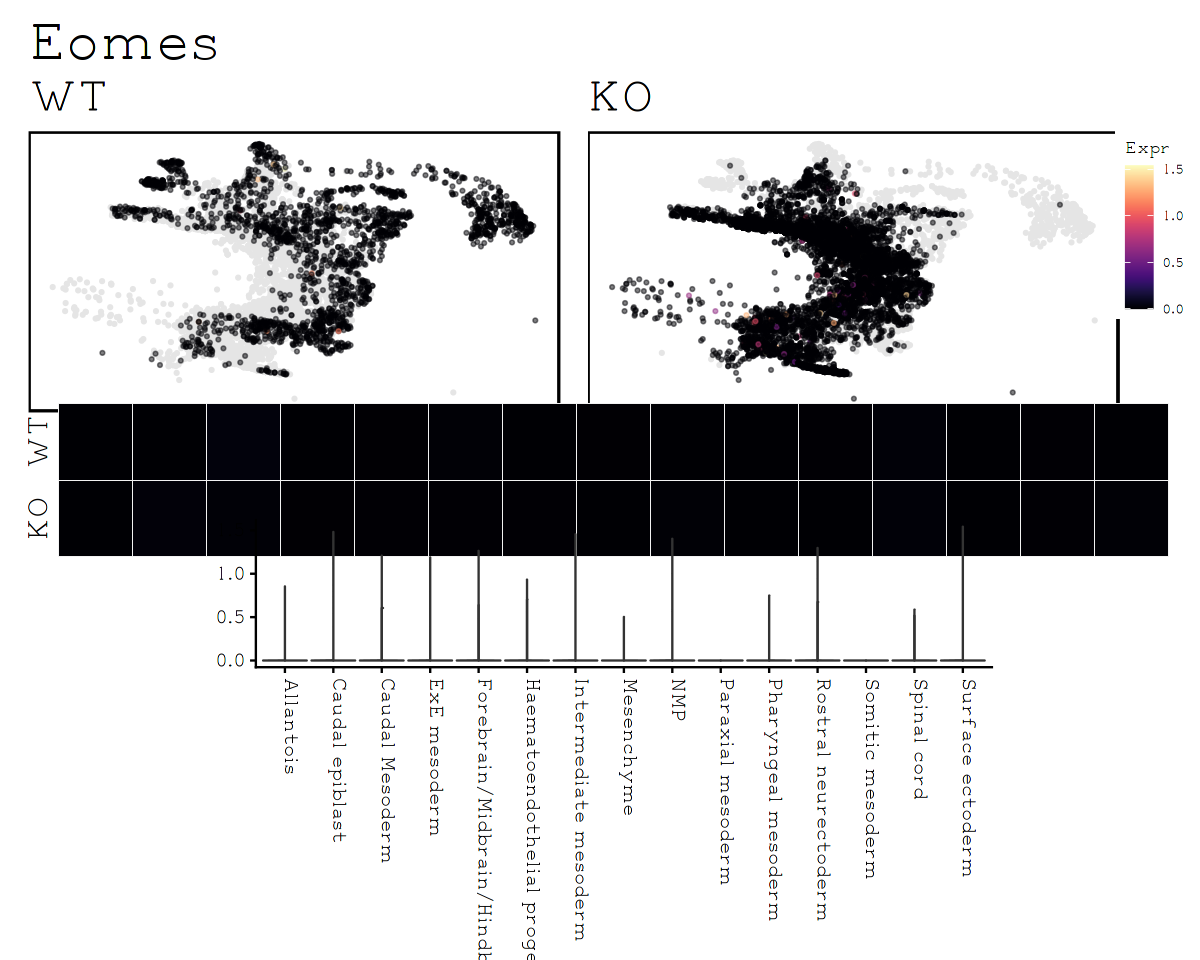

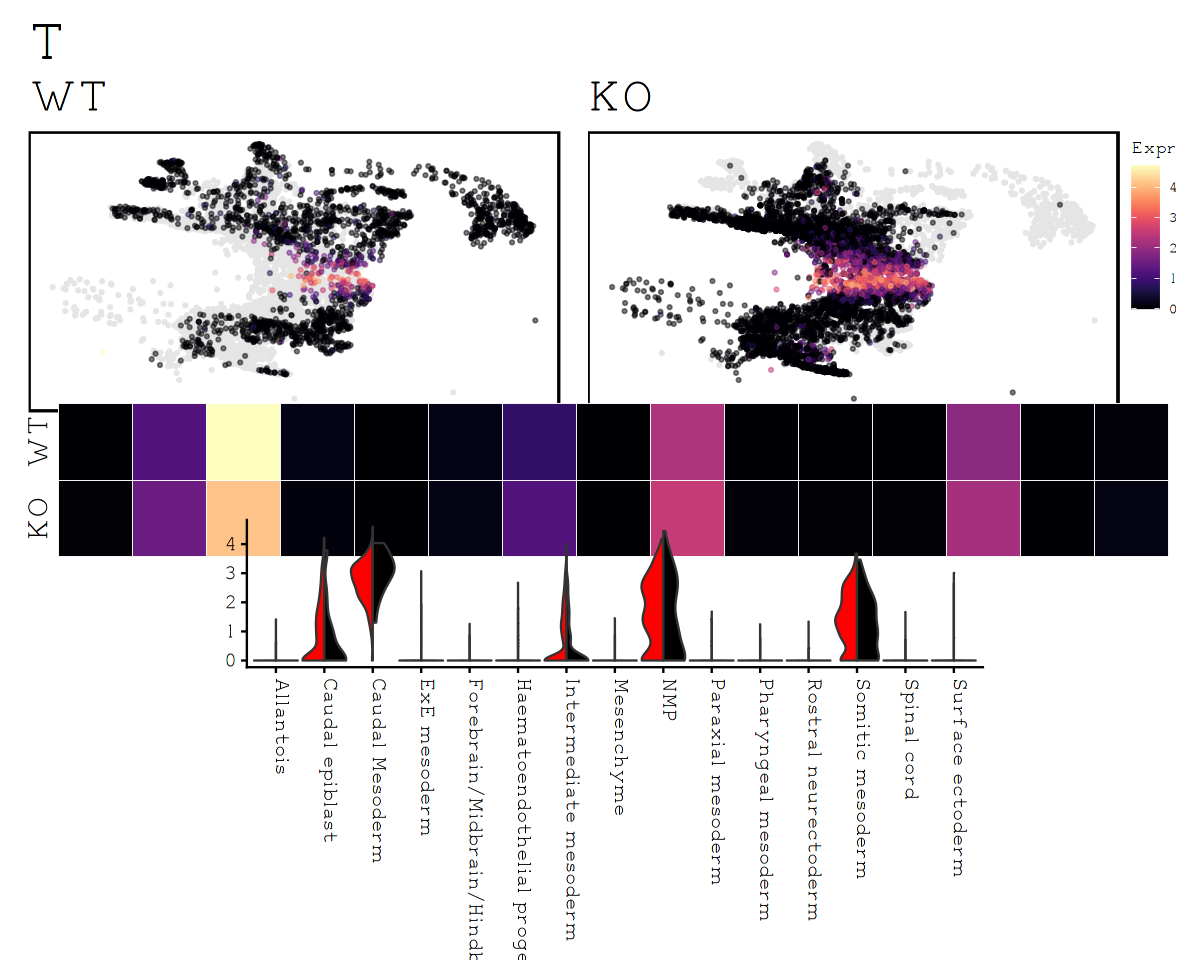

In [23]:
for(i in 1:length(plots)){
    suppressMessages(ggsave(paste0(plot_dir, 'gene_', names(plots[i]), '.png'), grid.arrange(plots[[i]]), device='png', width=8, height = 9))
}

### Gene scores -- WIP

In [184]:
plot_gene_score = function(x, name){
    score = Matrix::colMeans(logcounts(sce[x,]))/max(Matrix::colMeans(logcounts(sce[x,])))

    p1 = ggplot(WT, aes(umapX.mapped, umapY.mapped, col=as.vector(score[cell]))) + 
            geom_point(data=KO, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
            geom_point(size = 0.7, alpha = 0.5) + 
            scale_color_viridis(option='magma', begin=0, end = 0.5) + 
            labs(title = paste0(name, ' score'), 
                subtitle = 'WT control') +
            umap_theme
    p2 = ggplot(KO, aes(umapX.mapped, umapY.mapped, col=as.vector(score[cell])))  + 
        geom_point(data=WT, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        umap_theme

df = data.frame('cell'=meta$cell, 'celltype' = meta$celltype.mapped, 'tdTom'= meta$tdTom, 'gene'= as.vector(Matrix::colMeans(logcounts(sce[x,]))))
df = df %>% group_by(celltype, tdTom) %>% summarize('mean' = mean(gene))#/max(gene))    

    p4 = ggplot(meta[meta$celltype.mapped %in% keep,], aes(celltype.mapped, tdTom, fill=as.vector(score)[meta$celltype.mapped %in% keep])) +       
        scale_fill_viridis(option='magma', name='') + 
        scale_y_discrete(labels=c('KO', 'WT'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 30, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 10, color='black'),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2)

        p3=ggplot(df[df$celltype %in% keep,], aes(celltype, tdTom, fill=mean)) +       
        scale_fill_viridis(option='magma', name='', end = max(df$mean)/max(as.vector(Matrix::colMeans(logcounts(sce[x,]))))) + 
        scale_y_discrete(labels=c('WT', 'KO'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 20, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 14, color='black'),
              axis.text.x=element_blank(),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2)
    
    grid.arrange(arrangeGrob(p1, p2, ncol=2), p3, p4, ncol=1)
}

In [ ]:
Tgfs = c('Tgfbr1','Tgfbr2','Tgfbr3')
Bmps = c('Bmp1', 'Bmp2', 'Bmp3', 'Bmp4', 'Bmp5', 'Bmp6', 'Bmp7')
Activins = c('Acvr1', 'Acvr1b', 'Acvr1c')
Smad159 = c('Smad1', 'Smad5', 'Smad9')
Smad23 = c('Smad2', 'Smad3')

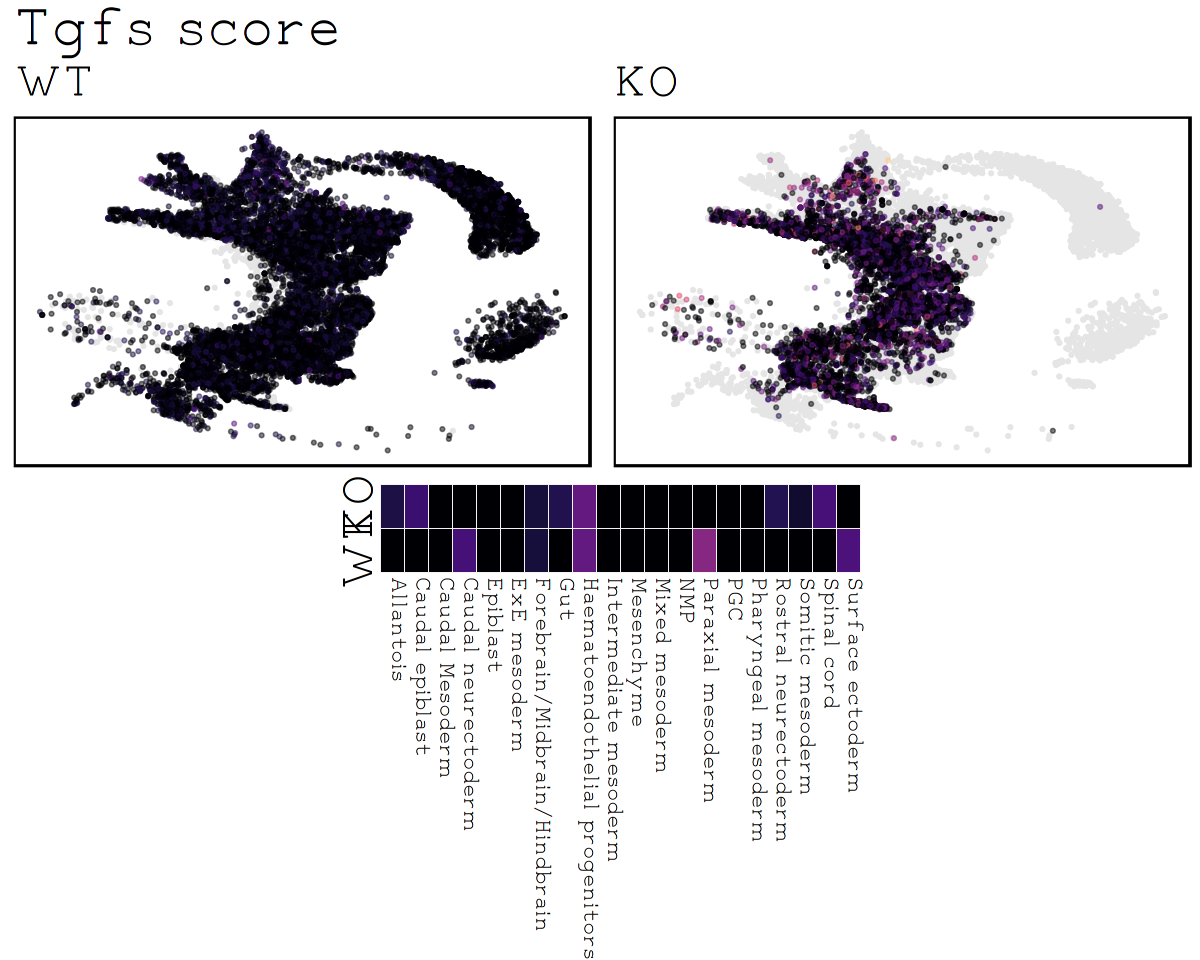

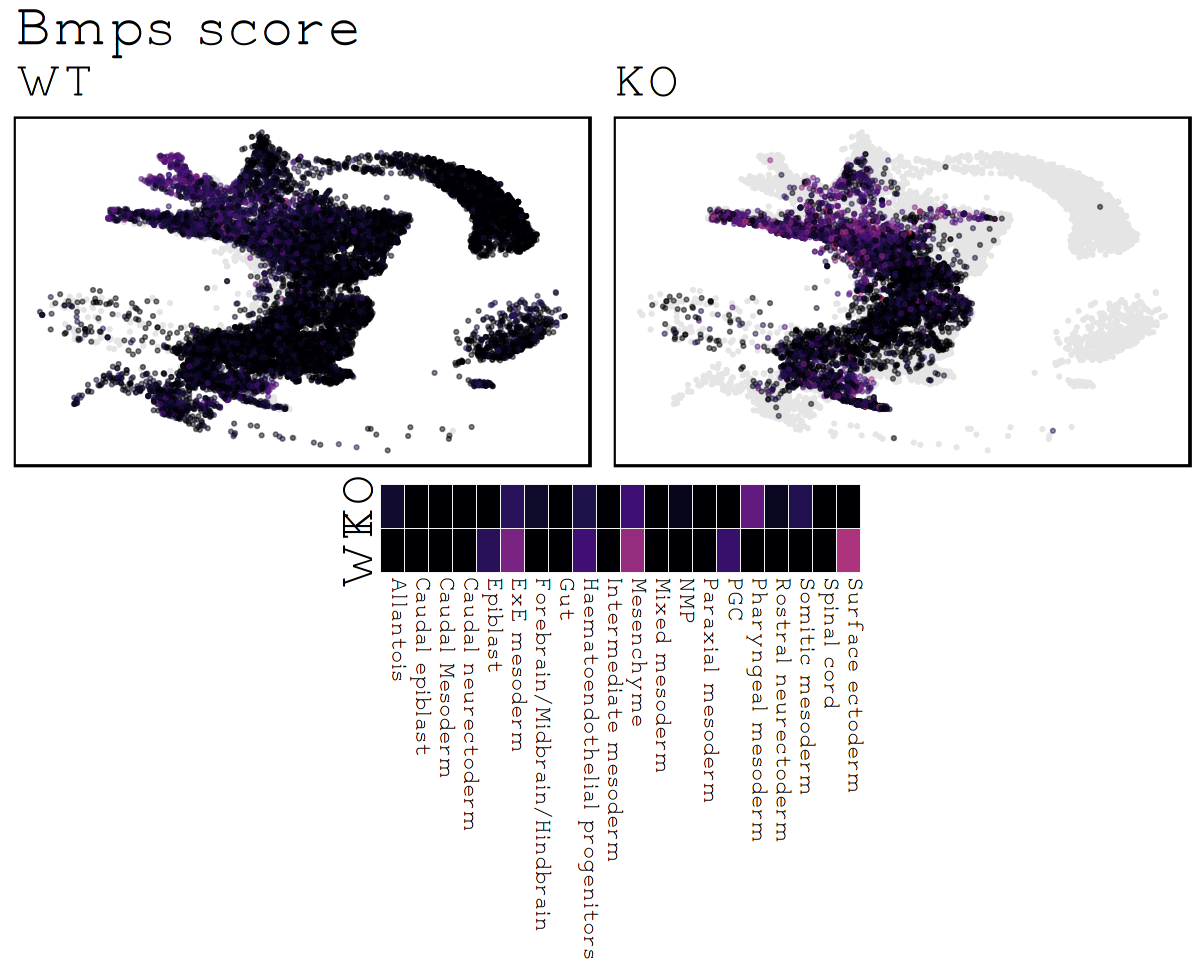

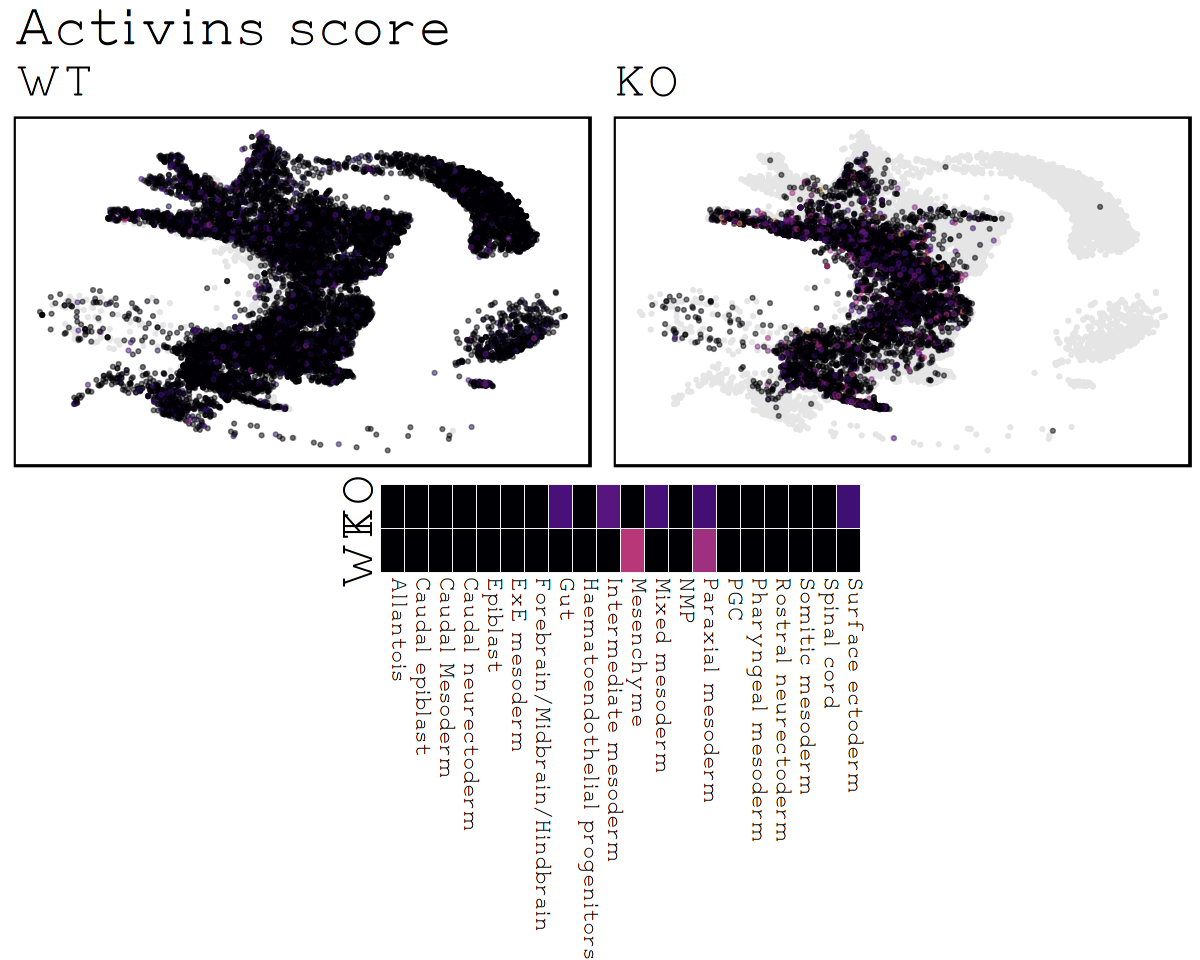

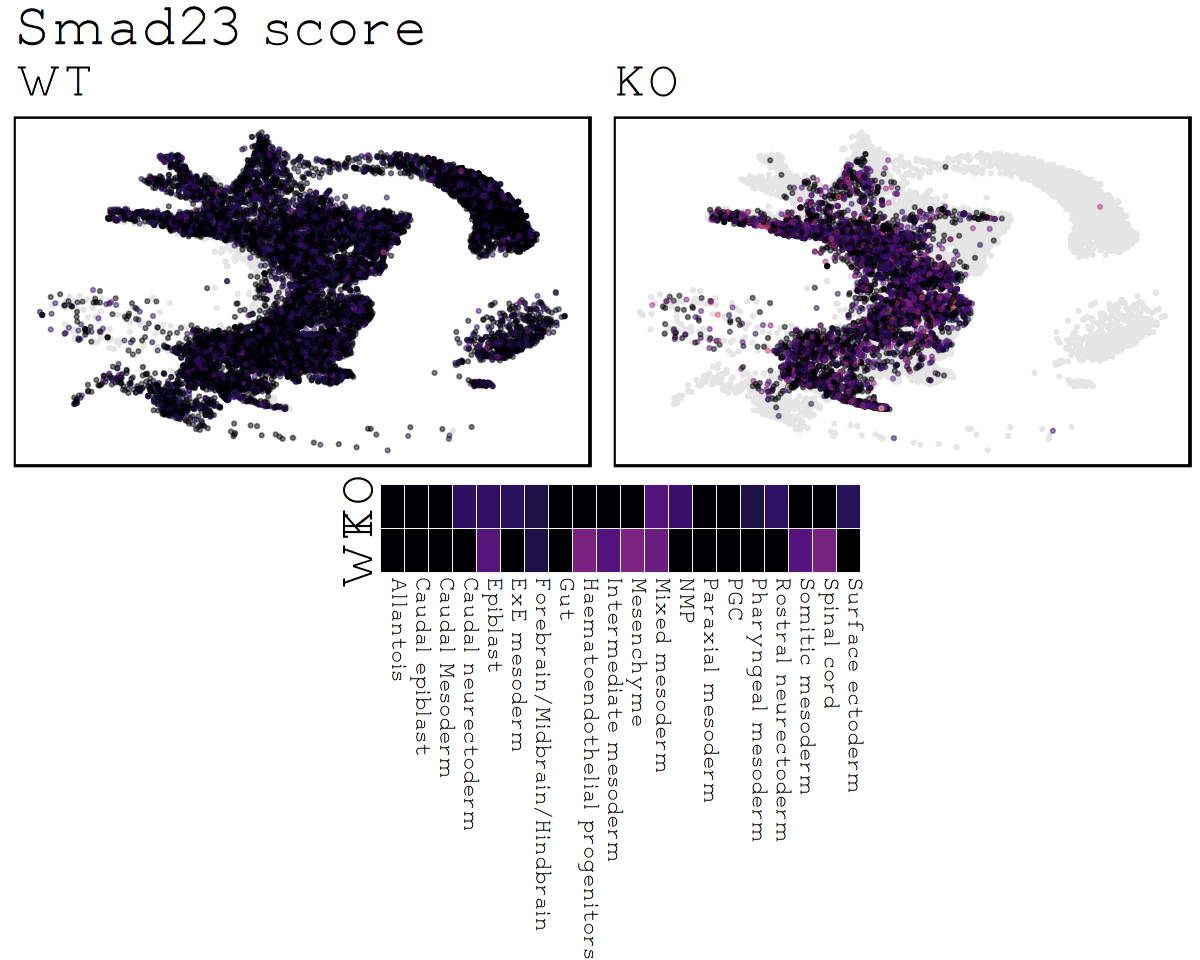

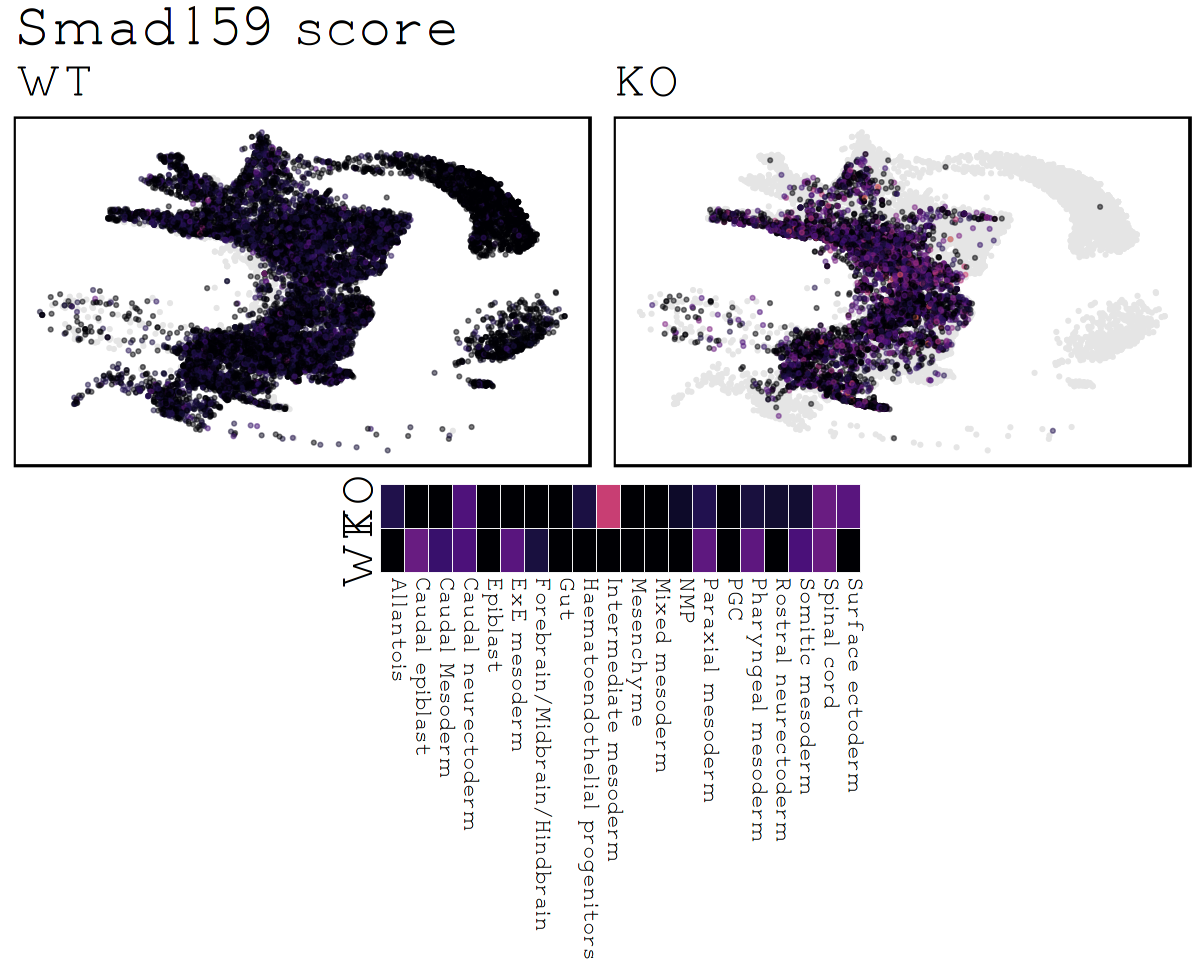

In [126]:
name = 'Tgfs'
plot = plot_gene_score(Tgfs, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Bmps'
plot = plot_gene_score(Bmps, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Activins'
plot = plot_gene_score(Activins, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Smad23'
plot = plot_gene_score(Smad23, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Smad159'
plot = plot_gene_score(Smad159, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)

### EdgeR DEG analysis

In [24]:
opts = list()
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

# Function to differential expression
# - sce: SingleCellExperiment object with the column "group" in the colData
# - groups: the names of the two groups
# - min_detection_rate_per_group: minimum detection rate per group
doDiffExpr <- function(sce, groups, min_detection_rate_per_group = 0.50) {
    
  # Sanity checks
  if (!is(sce, "SingleCellExperiment")) stop("'sce' has to be an instance of SingleCellExperiment")
  stopifnot(length(groups)==2)

  # Filter genes by detection rate per group
  cdr_A <- rowMeans(logcounts(sce[,sce$group==groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(logcounts(sce[,sce$group==groups[2]])>0) >= min_detection_rate_per_group
  out <- .edgeR(sce[cdr_B | cdr_A,]) %>% .[,log_padj_fdr:= -log10(padj_fdr)]
  
  return(out)
}


.edgeR <- function(sce) {
  
  # Convert SCE to DGEList
  
  sce_edger <- scran::convertTo(sce, type="edgeR")
 # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    
  # Define design matrix (with intercept)
  cdr <- colMeans(logcounts(sce)>0)
  design <- model.matrix(~cdr+sce$group)
  
  # Estimate dispersions
  sce_edger  <- estimateDisp(sce_edger,design)
  
  # Fit GLM
  fit <- glmQLFit(sce_edger,design)
  
  # Likelihood ratio test
  lrt <- glmQLFTest(fit)
  
  # Construct output data.frame
  out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
    setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
    .[,c("logCPM","LR"):=NULL]
  
  return(out)
}

################
## Plot utils ##
################


gg_volcano_plot <- function(to.plot, top_genes=10, xlim=NULL, ylim=NULL, label_groups = NULL) {
  
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot)
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)]
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=105), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-6,6)) +
    scale_y_continuous(limits=c(0,115)) +
    annotate("text", x=0, y=115, size=4, label=sprintf("(%d)", all)) +
    annotate("text", x=-5, y=115, size=4, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=5, y=115, size=4, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=head(to.plot[sig==T],n=top_genes), aes(x=logFC, y=-log10(padj_fdr+1e-100), label=gene), max.overlaps=Inf, size=4) +
    theme_classic() +
    theme(
      axis.text = element_text(size=rel(0.75), color='black'),
      axis.title = element_text(size=rel(1.0), color='black'),
      legend.position="none"
    )
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

#### DEG between Tom+ and Tom- per celltype

In [25]:

sce$group = meta$exp
degs = lapply(unique(meta$celltype.mapped), function(x){     #unique(meta$celltype.mapped)
        sce_deg = sce[, meta$celltype.mapped==x]
        opts$groups = c('WT', X)
        sce_deg$group = factor(sce_deg$group, levels = opts$groups)
        message(x)
        if(length(sce_deg$group[sce_deg$group == opts$groups[1]]) > 1 &    # Only select celltypes with 2 or more cells per group
            length(sce_deg$group[sce_deg$group == opts$groups[2]]) > 1){
            cdr.dt <- data.table(
              rownames(sce_deg),
              rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
              rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
            ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

            out <- doDiffExpr(sce_deg, opts$groups) %>%
              # Add sample statistics
              .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
              .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
              # Add gene statistics
            #  merge(cdr.dt, all.y=T, by="gene") %>%
              # Calculate statistical significance
              .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
              .[is.na(sig),sig:=FALSE] %>% 
              setorder(-sig, padj_fdr, na.last=T)

            # Parse columns
            out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]
            }
        })

Rostral neurectoderm

Intermediate mesoderm

Allantois

Surface ectoderm

Caudal Mesoderm

ExE mesoderm

Forebrain/Midbrain/Hindbrain

Somitic mesoderm

Mixed mesoderm

Spinal cord

Caudal epiblast

NMP

Paraxial mesoderm

Caudal neurectoderm

Epiblast

Pharyngeal mesoderm

Haematoendothelial progenitors

Endothelium

Mesenchyme

PGC

Neural crest

Gut

Nascent mesoderm

Primitive Streak

Visceral endoderm

Def. endoderm

ExE endoderm

Erythroid2

Blood progenitors 2

Erythroid3

Erythroid1

Cardiomyocytes

ExE ectoderm

Blood progenitors 1



In [26]:
tomato_DEGs = rbindlist(degs)

In [27]:
write.csv(tomato_DEGs, paste0(out_dir, 'tomato_DEGs_edgeR_nonfiltered.csv'), row.names=FALSE)

In [28]:
plots = list()
for(i in 1:length(unique(tomato_DEGs$celltype))){
    plots[[i]] = gg_volcano_plot(tomato_DEGs[tomato_DEGs$celltype == unique(tomato_DEGs$celltype)[i],], top_genes = 25) + 
            labs(title = unique(tomato_DEGs$celltype)[i],
                 subtitle = paste0('n tdTom-: ', unique(tomato_DEGs$groupA_N)[i], ', n tdTom+: ', unique(tomato_DEGs$groupB_N)[i]))
}
names(plots) = gsub(" ", "_", unique(tomato_DEGs$celltype))
names(plots) = gsub("/", "_", unique(names(plots)))

In [29]:
pdf(sprintf('%sDEGs_across_celltypes_edgeR_nonfiltered.pdf', plot_dir))
    plots
dev.off()

Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning 

$Rostral_neurectoderm

$Intermediate_mesoderm

$Allantois

$Surface_ectoderm

$Caudal_Mesoderm

$ExE_mesoderm

$Forebrain_Midbrain_Hindbrain

$Somitic_mesoderm

$Spinal_cord

$Caudal_epiblast

$NMP

$Paraxial_mesoderm

$Caudal_neurectoderm

$Pharyngeal_mesoderm

$Haematoendothelial_progenitors

$Endothelium

$Mesenchyme

$Neural_crest

$Gut


png 
  2

In [30]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

In [31]:
WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/old/tomato_DEGs_edgeR.csv')

In [32]:
tomato_DEGs = tomato_DEGs[!tomato_DEGs$gene %in% exl_names & !tomato_DEGs$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]
write.csv(tomato_DEGs, paste0(out_dir, 'tomato_DEGs_edgeR_filtered.csv'), row.names=FALSE)

In [33]:
tomato_DEGs = fread(paste0(out_dir, 'tomato_DEGs_edgeR_filtered.csv'))

In [34]:
plots = list()
for(i in 1:length(unique(tomato_DEGs$celltype))){
    plots[[i]] = gg_volcano_plot(tomato_DEGs[tomato_DEGs$celltype == unique(tomato_DEGs$celltype)[i],], top_genes = 25) + 
            labs(title = unique(tomato_DEGs$celltype)[i],
                 subtitle = paste0('n tdTom-: ', unique(tomato_DEGs$groupA_N)[i], ', n tdTom+: ', unique(tomato_DEGs$groupB_N)[i]))
}
names(plots) = gsub(" ", "_", unique(tomato_DEGs$celltype))
names(plots) = gsub("/", "_", unique(names(plots)))

In [35]:
pdf(sprintf('%sDEGs_across_celltypes_edgeR_filtered.pdf', plot_dir))
    plots
dev.off()

Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning 

$Rostral_neurectoderm

$Intermediate_mesoderm

$Allantois

$Surface_ectoderm

$Caudal_Mesoderm

$ExE_mesoderm

$Forebrain_Midbrain_Hindbrain

$Somitic_mesoderm

$Spinal_cord

$Caudal_epiblast

$NMP

$Paraxial_mesoderm

$Caudal_neurectoderm

$Pharyngeal_mesoderm

$Haematoendothelial_progenitors

$Endothelium

$Mesenchyme

$Neural_crest

$Gut


png 
  2

#### DEG between Tom+ and Tom- all celltype

In [37]:
# DEG between Tom+ and Tom- all celltype
sce$group = meta$exp
sce_deg = sce
opts$groups = c('WT', X)
sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
      rownames(sce_deg),
      rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
      rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
      # Add sample statistics
      .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
      .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
      # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
      # Calculate statistical significance
      .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
      .[is.na(sig),sig:=FALSE] %>% 
      setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


In [38]:
tomato_DEGs = out

In [39]:
write.csv(tomato_DEGs, paste0(out_dir, 'tomato_DEGs_edgeR_all_nonfiltered.csv'), row.names=FALSE)

In [40]:
plots = list()
    plots =  gg_volcano_plot(tomato_DEGs, top_genes = 25) + 
            labs(title = 'All celltypes',
                 subtitle = paste0('n tdTom-: ', unique(tomato_DEGs$groupA_N), ', n tdTom+: ', unique(tomato_DEGs$groupB_N)))


In [41]:
head(tomato_DEGs, 5)

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
Hbb-bh1,-12.073,0,0,Inf,2254,9679,WT,Eomes,TRUE
Hbb-y,-11.368,0,0,Inf,2254,9679,WT,Eomes,TRUE
Hba-x,-11.104,0,0,Inf,2254,9679,WT,Eomes,TRUE
Hba-a1,-9.429,0,0,Inf,2254,9679,WT,Eomes,TRUE
Hba-a2,-8.236,0,0,Inf,2254,9679,WT,Eomes,TRUE


In [42]:
pdf(sprintf('%sDEGs_all_celltypes_edgeR_nonfiltered.pdf', plot_dir))
    plots
dev.off()

Warning message:
“Removed 5 rows containing missing values (geom_point).”
Warning message:
“Removed 5 rows containing missing values (geom_text_repel).”


png 
  2

In [43]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

In [44]:
WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

In [45]:
out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]
write.csv(out, paste0(out_dir, 'tomato_DEGs_all_celltypes_edgeR_filtered.csv'), row.names=FALSE)

In [46]:
plot = gg_volcano_plot(out, top_genes = 35) + 
            labs(title = 'DEGs all celltypes',
                 subtitle = paste0('n tdTom-: ', unique(out$groupA_N), 
                                   ', n tdTom+: ', unique(out$groupB_N)))

In [47]:
pdf(sprintf('%sDEGs_all_celltypes_edgeR_filtered.pdf', plot_dir))
    plot
dev.off()

Warning message:
“Removed 5 rows containing missing values (geom_point).”
Warning message:
“Removed 5 rows containing missing values (geom_text_repel).”


png 
  2

In [9]:
celltype_DEGs = fread(paste0(out_dir, 'celltype_DEGs.csv'))

In [50]:
head(celltype_DEGs %>% filter(groupA == 'Epiblast'))

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
Pim2,-3.206,8.02e-186,1.90e-182,181.721,125,27651,Epiblast,other,TRUE
Six3,-3.180,2.65e-169,3.14e-166,165.503,125,27651,Epiblast,other,TRUE
Dnmt3b,-2.664,2.51e-162,1.98e-159,158.703,125,27651,Epiblast,other,TRUE
Hesx1,-3.172,7.02e-154,4.16e-151,150.381,125,27651,Epiblast,other,TRUE
Otx2,-2.846,3.15e-131,1.49e-128,127.826,125,27651,Epiblast,other,TRUE
Pou3f1,-2.434,4.65e-74,1.84e-71,70.736,125,27651,Epiblast,other,TRUE


In [30]:
plots = list()
for(i in 1:length(unique(celltype_DEGs$groupA))){
    plots[[i]] = gg_volcano_plot(celltype_DEGs[celltype_DEGs$groupA == unique(celltype_DEGs$groupA)[i],])+ ggtitle(unique(celltype_DEGs$groupA)[i])
}
names(plots) = gsub(" ", "_", unique(celltype_DEGs$groupA))
names(plots) = gsub("/", "_", unique(names(plots)))

In [32]:
pdf(sprintf('%scelltype_markers_edgeR.pdf', plot_dir))
    plots
dev.off()

Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”
Warning 

$Rostral_neurectoderm

$Intermediate_mesoderm

$Allantois

$Surface_ectoderm

$Caudal_Mesoderm

$ExE_mesoderm

$Forebrain_Midbrain_Hindbrain

$Somitic_mesoderm

$Mixed_mesoderm

$Spinal_cord

$Caudal_epiblast

$NMP

$Paraxial_mesoderm

$Caudal_neurectoderm

$Epiblast

$Pharyngeal_mesoderm

$Haematoendothelial_progenitors

$Erythroid1

$Erythroid2

$Endothelium

$Mesenchyme

$Erythroid3

$Blood_progenitors_1

$Cardiomyocytes

$ExE_ectoderm

$Blood_progenitors_2

$Neural_crest

$Def._endoderm

$Gut

$Notochord

$PGC

$Primitive_Streak

$Visceral_endoderm

$Nascent_mesoderm

$Parietal_endoderm

$ExE_endoderm

$Anterior_Primitive_Streak


png 
  2

In [237]:
unique(meta$celltype.mapped)

[1] "Rostral neurectoderm"           "Intermediate mesoderm"         
 [3] "Allantois"                      "Surface ectoderm"              
 [5] "Caudal Mesoderm"                "ExE mesoderm"                  
 [7] "Forebrain/Midbrain/Hindbrain"   "Somitic mesoderm"              
 [9] "Mixed mesoderm"                 "Spinal cord"                   
[11] "Caudal epiblast"                "NMP"                           
[13] "Paraxial mesoderm"              "Caudal neurectoderm"           
[15] "Epiblast"                       "Pharyngeal mesoderm"           
[17] "Haematoendothelial progenitors" "Erythroid1"                    
[19] "Erythroid2"                     "Endothelium"                   
[21] "Mesenchyme"                     "Erythroid3"                    
[23] "Blood progenitors 1"            "Cardiomyocytes"                
[25] "ExE ectoderm"                   "Blood progenitors 2"           
[27] "Neural crest"                   "Def. endoderm"                 
[29] "Gut"                            "Notochord"                     
[31] "PGC"                            "Primitive Streak"              
[33] "Visceral endoderm"              "Nascent mesoderm"              
[35] "Parietal endoderm"              "ExE endoderm"                  
[37] "Anterior Primitive Streak"

In [267]:
embryo_mesoderm = c('Cardiomyocytes', 
                    'Caudal Mesoderm', 
                   # 'Anterior Primitive Streak', 
                    'Endothelium', 
                    'Intermediate mesoderm', 
                    'Nascent mesoderm', 
                    'Mixed mesoderm', 
                    'NMP', 
                    'Paraxial mesoderm', 
                    'Pharyngeal mesoderm', 
                    'Somitic mesoderm')

ExE_mesoderm = c('Allantois', 'ExE mesoderm', 'Haematoendothelial progenitors', 'Mesenchyme', 'Endothelium')

endoderm = c('Def. endoderm', 'Gut', 'Parietal endoderm', 'Visceral endoderm', 'ExE endoderm')

In [268]:
nrow(meta[meta$celltype.mapped %in% ExE_mesoderm,])

[1] 6276

In [242]:
opts = list()
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

In [258]:
    sce$group = meta$tdTom
    sce_deg = sce[, meta$celltype.mapped %in% embryo_mesoderm]
    opts$groups = c('negative', 'positive')
    sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
    rownames(sce_deg),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
    # Add sample statistics
    .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
    .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
    # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
    # Calculate statistical significance
    .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
    .[is.na(sig),sig:=FALSE] %>% 
    setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]

In [246]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

In [247]:
WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

In [248]:
out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]

In [253]:
write.csv(out, paste0(out_dir, 'tomato_DEGs_embry_mesoderm_edgeR_filtered.csv'), row.names=FALSE)

In [254]:
pdf(sprintf('%sDEGs_embry_mesoderm_edgeR_filtered.pdf', plot_dir))
    gg_volcano_plot(out, top_genes=50)
dev.off()

png 
  2

In [261]:
    sce$group = meta$tdTom
    sce_deg = sce[, meta$celltype.mapped %in% endoderm]
    opts$groups = c('negative', 'positive')
    sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
    rownames(sce_deg),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
    # Add sample statistics
    .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
    .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
    # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
    # Calculate statistical significance
    .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
    .[is.na(sig),sig:=FALSE] %>% 
    setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]

#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]

In [263]:
write.csv(out, paste0(out_dir, 'tomato_DEGs_endoderm_edgeR_filtered.csv'), row.names=FALSE)

In [264]:
pdf(sprintf('%sDEGs_endoderm_edgeR_filtered.pdf', plot_dir))
    gg_volcano_plot(out, top_genes=50)
dev.off()

png 
  2

In [269]:
    sce$group = meta$tdTom
    sce_deg = sce[, meta$celltype.mapped %in% ExE_mesoderm]
    opts$groups = c('negative', 'positive')
    sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
    rownames(sce_deg),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
    # Add sample statistics
    .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
    .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
    # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
    # Calculate statistical significance
    .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
    .[is.na(sig),sig:=FALSE] %>% 
    setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]

#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]

In [270]:
write.csv(out, paste0(out_dir, 'tomato_DEGs_ExE_mesoderm_edgeR_filtered.csv'), row.names=FALSE)

In [271]:
pdf(sprintf('%sDEGs_ExE_mesoderm_edgeR_filtered.pdf', plot_dir))
    gg_volcano_plot(out, top_genes=50)
dev.off()

png 
  2